<a href="https://colab.research.google.com/github/Sanraj-Lachhiramka/Clustering-Based-Portfolio-Optimization-for-Algorithmic-Trading/blob/main/Algorithmic_Trading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning in Trading

Few use cases of ML in Trading:

###Supervised Learning


*   Signal generation through prediction. For example, buy or sell signals, based on predicted returns or direction.
*   Risk management through prediction. For example determining position sizing and stop-loss levels to have more optimized risk.

###Unsupervised Learning


*   Extract insights from the data. For example discover patterns, relationships and structures.

###Challenges to applying ML in trading:
(Reflexivity - Theory that investor perceptions influence market fundamentals, which in turn change investor perceptions, creating self-reinforcing feedback loops. Instead of markets moving toward equilibrium, they often diverge, causing bubbles to rise and crash as prices drive reality rather than merely reflecting it. )


*   Very hard to predict returns or prices.
*   Quite hard to predict return signs.
*   Hard to predict economic indicator.
*   Not so hard to predict volatility.

Furthermore, some technical challenges are overfitting and generalization, non-stationarity and regime shifts, as well interpretation of black-box models.


## The Workflow Process

1. Collect and Prepare the data.
2. Develop a hypothesis for a strategy.
3. Coding and training the model.
4. Backtest the strategy.
















# Project 1: Unsupervised Learning Trading Strategy

Unsupervised learning in trading involves using machine learning techniques to analyze financial data and discover patterns, relationships, and structures within the data without any labeled or predefined target variable. Unlike supervised learning, where the model is trained to make predictions, unsupervised learning focuses on extracting insights from data.

Here's how unsupervised learning is applied in trading:



*   **Clustering**
*  **Dimensionality Reduction**
*   **Anomaly Detection**
*   **Market Regime Detection**  - Market regime change detection using machine learning involves applying advanced algorithms to identify and predict significant shifts in market behavior, trading patterns, and risk characteristics
*   **Protfolio Optimization**  - quantitative process of selecting the best mix of assets to maximize expected returns for a given level of risk, or to minimize risk for a target return.





### Unsupervised Learning for Algorithmic Trading

This project explores an unsupervised machine learning approach to develop an algorithmic trading strategy. It involves collecting S&P 500 stock data, engineering various technical and fundamental features, and then applying K-means clustering to group similar assets monthly. Subsequently, portfolios are optimized using the Efficient Frontier to maximize the Sharpe ratio, with performance benchmarked against the S&P 500. The goal is to uncover hidden patterns in financial data for enhanced asset selection and portfolio management.

#What we will do:



*   Download SP500 stocks prices data. - S&P 500 (Standard and Poor's 500) is a stock market index tracking the stock performance of 500 leading companies listed on stock exchanges in the United States.
*   Calculate different technical indicators and features for each stock.
*   Aggregate on monthly level and filter for each month only top 150 most liquid stocks.
*   Calculate monthly returns for different time-horizons to add to features.
*   Download Frame-French Factors and calculate rolling factor betas for each stock.
*   For each month fit a K-means clustering model to group similar assets based on their features.
*   For each month select assets based on the cluster and form a protfolio based on Efficient Frontier max sharpe ratio profolio optimization.
*   Visualize the protfolio returns and compare to SP500 returns.

!Limitation! We are going to use most recent SP500 stocks list, which means that there may be a survivorship bias in the list, in reality you have to use survivorship free data.


Survivorship bias is a logical error focusing on people or things that "survived" a process while overlooking those that did not, leading to false conclusions. It occurs when analyzing only successful examples (winners) and ignoring failed ones, creating an overly optimistic, distorted perception of reality.



##ALL PACKAGES NEEDED



*   pandas, numpy, matplotlib, pandas_datareader, statsmodel, datetime, yfinance, sklearn, PyProtfolioOpt


1. **Download/Load SP500 stock prices data**

In [ ]:
!pip install pandas-ta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 109.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 17.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninst

In [ ]:
 # RollingOLS performs regression over a moving window (e.g., 60-day rolling beta).
# Common use: estimating time-varying relationships like rolling CAPM beta.
from statsmodels.regression.rolling import RollingOLS

# pandas_datareader - allows you to download financial and economic data directly into pandas DataFrames.
# Used to fetch financial/economic data from sources like: FRED, Yahoo Finance, World Bank
# from pandas_datareader import data as web (not working)

import matplotlib.pyplot as plt

#Imports the main API of statsmodels
import statsmodels.api as sm

import pandas as pd
import numpy as np
import datetime as dt

# Imports yfinance. Used to download stock price data directly.
# yfinance is a Python library that allows you to download financial market data directly from Yahoo Finance.
import yfinance as yf

#Provides technical indicators like: RSI, MACD, Bollinger Bands, Moving averages
import pandas_ta
import warnings
warnings.filterwarnings('ignore')

What is **RollingOLS**?

OLS - Ordinary Least Squares

RollingOLS is a class from the statsmodels library that performs rolling (moving window) linear regression.

Instead of fitting one regression over your entire dataset, it:

- Chooses a fixed window size (e.g., 60 observations)

- Runs OLS regression on the first 60 rows

- Moves the window forward by one step

- Runs regression again

- Repeats until the end of the dataset

This produces **time-varying regression coefficients**.



In finance and time-series analysis, relationships often change over time.

Example:

- A stock’s beta vs. the market is not constant.

- Economic relationships evolve.

- Factor exposures shift.

RollingOLS helps measure those changing relationships.

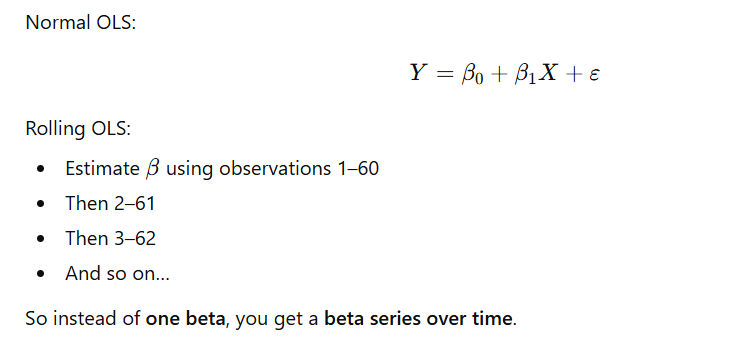

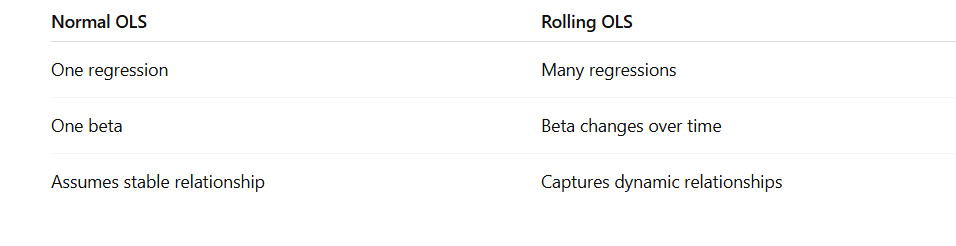

A **ticker** (or ticker symbol) is a short, unique code used to identify a publicly traded stock on an exchange.

Example: A stock’s license plate number in the market.

In [ ]:

# Load Nifty 500 list from NSE
url = "https://archives.nseindia.com/content/indices/ind_nifty500list.csv"
nifty500 = pd.read_csv(url)
# Downloads the official Nifty 500 constituents list from NSE.
# Stores it as a pandas DataFrame.
# This CSV contains company names, symbols, industry, etc.

print(nifty500.head())


# Fix symbols for Yahoo Finance
nifty500['Symbol'] = nifty500['Symbol'].str.replace('.', '-', regex=False)
# Some NSE symbols contain dots (.), but Yahoo Finance uses dashes (-) instead.
# This line ensures compatibility with Yahoo Finance.


# Add .NS for NSE stocks
symbols_list = nifty500['Symbol'].astype(str) + ".NS"
# Yahoo Finance requires NSE stocks to end with
# Now symbols_list contains all 500 NSE tickers in Yahoo format.

# Date range
end_date = '2026-02-23'
start_date = pd.to_datetime(end_date) - pd.DateOffset(years=8)
# Last 8 years data

# Downloads daily OHLCV data: Open, High, Low, Close, Volume
df = yf.download(
    tickers=symbols_list.tolist(), # Downloads All 500 stocks #Why .tolist()? Because symbols_list is a pandas Series. yfinance expects a Python list, not a Series.
    start=start_date,
    end=end_date,
   # group_by='ticker', # Data grouped by stock
    auto_adjust=False, # auto_adjust=False → you get both: Close (raw price), Adj Close (adjusted price) By default its true
    # auto_adjust=True, # Adjusts prices for splits & dividends
                      #Why this matters? Example:
                      # Suppose a stock:
                      # Was ₹200
                      # Then did a 1:2 split
                      # Price becomes ₹100
                      # Without adjustment, your chart would show a huge price drop.
                      # That’s wrong — it’s just a split.

                      # With auto_adjust=True:
                      # All past prices are adjusted
                      # The price series becomes smooth
                      # Returns are accurate


                      # removes the Adj Close colum
                      # 💡 Pro quant tip:
                      # For factor models, many researchers only use adj close and ignore close completely to avoid accidental use of unadjusted prices.
    threads=True # Faster parallel downloading
).stack() # Reshapes wide format → long format


# Clean Index & Column Names
df.index.names = ['date', 'ticker'] # Index becomes: (date, ticker)
df.columns = df.columns.str.lower()# Column names become lowercase: open, high, low, close, volume

# Remove fake rows where stock had no data yet
df = df.dropna(subset=['open','high','low','close','adj close'], how='all')
#  means that a row will be dropped only if ALL of the specified columns (in subset) contain missing values (NaN/None).

print(df.head())
print(df.columns)


# This script
# 📥 Downloads the full Nifty 500 stock universe
# 📅 Pulls 8 years of daily price data
# 🔄 Adjusts prices for splits/dividends
# 🧹 Cleans and reshapes data
# 📊 Makes it ready for quantitative analysis


#**2. Calculate features and technical indicators for each stock.**
- Garman-Klass Volatility
- RSI
- Bollinger Bands
- ATR
- MACD
- Dollar Volume

###**Volatility**

**Volatility** is a simple term for how much something's price or value changes over time;

- High volatility means big, fast price swings (risky), while low volatility means stable, gradual changes (less risky).

- It's a measure of unpredictability, showing how much an asset's price moves up or down, often calculated using standard deviation.

**Period**

- The number of past data points (usually candles/bars) used in the calculation.

- It defines the lookback window.

- How it affects indicators
    - Short period (e.g., 5–10)

        - More sensitive

        - Reacts quickly

        - More noise

        - More false signals

    - Long period (e.g., 50–200)

        - Smoother

        - Slower reaction
        
        - Fewer signals

        - More stable trends

- Intuition

    - Think of period as:

      "How much recent history do I want this indicator to care about?"

      - Small period → cares mostly about recent moves
      - Large period → cares about longer-term behavior
  
- What “period” means in practice

    - If you're using:

    - Daily chart

      - 14-period RSI → uses last 14 days

    - Hourly chart

      - 14-period RSI → uses last 14 hours

    - 5-minute chart

      - 14-period RSI → uses last 14 five-minute candles

So the period always depends on your timeframe.


**Higher Highs: The Hallmark of an Uptrend**
A "higher high" occurs when the price reaches a new peak that surpasses the previous high. This pattern signals that buyers are willing to pay more, reflecting strong bullish momentum.

When a series of higher highs is accompanied by higher lows (each low higher than the previous), it confirms an uptrend.

Why it matters to traders:

- Trend confirmation: Multiple higher highs and higher lows show a market in a sustained uptrend, ideal for buying opportunities.

- Entry signals: Traders often enter long positions after a pullback to a higher low, anticipating the next higher high.

**Higher Low**
- A **higher low** (HL) is a technical analysis pattern where an asset's price drops (pulls back) but stays above its previous, lower trough. It indicates weakening selling pressure and rising demand, serving as a key, bullish sign of an ongoing uptrend when combined with higher highs.

- Key Characteristics and Context
    - Definition: The latest low point in a price chart is higher than the previous low point.
    - Significance: It signals that investors are willing to buy at higher prices, often indicating a continuation of an upward trend.
    - Trading Strategy: Traders often look for a higher low to enter a "long" (buy) position, anticipating a move toward a new higher high.
    - Structure: It is part of the "stair-step" pattern of an uptrend (Higher Highs + Higher Lows).
    - Contra-indication: If a higher low is followed by a lower low instead of a higher high, it may suggest a trend reversal,

**Lower Lows: The Signature of a Downtrend**
A "lower low" forms when the price drops to a new trough below the previous low. This pattern is a clear sign of bearish sentiment, as sellers drive the price lower. A series of lower lows, especially when paired with lower highs, confirms a downtrend.

Why it matters to traders:

- Bearish market structure: Persistent lower lows and lower highs indicate strong selling pressure, favouring short-selling strategies.

- Exit or entry points: Traders may exit long positions or enter shorts when a lower high is followed by a fresh lower low.

**Lower high**
A "lower high" (LH) in trading is a technical analysis pattern where an asset's price peaks at a level lower than the previous peak, signaling weakening buying pressure and a potential shift toward a bearish (downward) trend. It indicates that sellers are entering the market at progressively lower prices.

Key Aspects of Lower Highs:
- Definition: Each successive peak is lower than the one before it.
- Market Sentiment: Suggests that bullish momentum is fading, often acting as a precursor to a downtrend or a reversal.
- Lower highs are crucial for identifying when a market is losing upward momentum, often signaling to traders that it may be time to exit long positions or consider shorting.

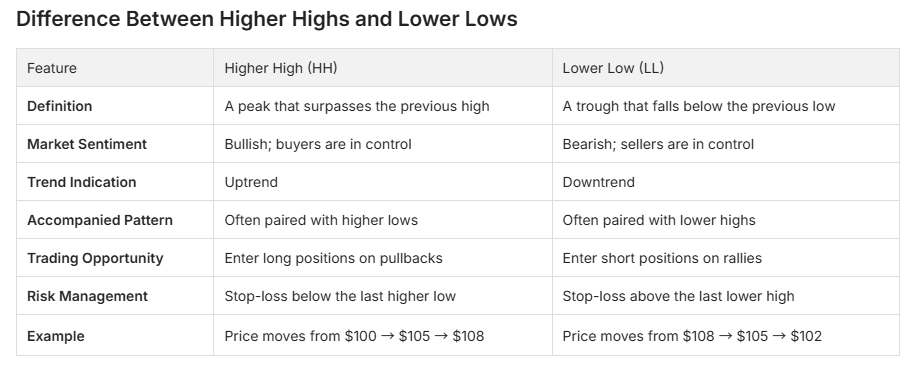

**Combining Higher Highs and Lower Lows: Trend Reversals**
While higher highs and higher lows indicate an uptrend, and lower lows and lower highs signal a downtrend, transitions between these patterns often mark trend reversals.

1. From uptrend to downtrend: If a market fails to make a new higher high and instead forms a lower low, it suggests the uptrend is weakening and a reversal could be imminent.

2. From downtrend to uptrend: Conversely, when a market stops making lower lows and instead forms a higher high, it may signal the start of a new uptrend.

Identifying these shifts early can help traders enter or exit positions at optimal moments.

**Practical Applications for Traders**
1. Identifying Entry and Exit Points

- In an uptrend, entering after a pullback to a higher low can provide a favourable risk-reward setup.

- In a downtrend, entering short after a lower high can maximise profit potential as the next lower low forms.


2. Risk Management


- Place stop-loss orders below the latest higher low in an uptrend to limit downside.

- In a downtrend, stops can be set above the most recent lower high.


3. Confirming Breakouts and Reversals



- A breakout above a prior high forming a new higher high can confirm the start of a bullish move.

- Failure to form a higher high or lower low may signal a weakening trend and possible reversal.


Experienced traders often combine higher high and lower low analysis with other tools:

- Trendlines: Drawing lines connecting successive highs or lows clarifies trend direction.

- Volume: Increasing volume on a higher high or lower low strengthens the signal.

- Indicators: Tools like RSI, MACD, or moving averages can validate trend strength or reveal divergence.


Use these indicators to validate the market structure before entering trades. A higher high accompanied by strong volume, RSI confirmation, and trendline alignment is far more reliable than relying on price alone.

**Timeframes matter:**

- Day traders may use these patterns on 1-minute or 5-minute charts for rapid trades.

- Swing traders and investors often focus on hourly, daily, or weekly charts for broader trends.

- Tip: Combining multiple timeframes such as confirming a daily trend with a 15-minute intraday chart can improve trade accuracy and timing.


**Real-World Example**
Imagine a stock moves from $100 to $110 (first high), pulls back to $105 (first low), then rallies to $115 (higher high), and drops to $108 (higher low). This  sequence  signals an uptrend, and a trader might buy at $108, expecting another higher high. If the stock then falls to $102 (lower low), it could indicate a trend reversal, prompting the trader to reconsider their position.

Note:
- Difference between a higher high and a lower high - A higher high exceeds the previous peak, signaling bullish momentum. A lower high fails to surpass the previous peak, indicating weakening buyers and potential downtrend.


- If a higher high is a false breakout?
Look for reversal candles, wicks, low volume, or failure to sustain above resistance. Combining with indicators like RSI or MACD can confirm if momentum is real.








### 1. **Garman–Klass Volatility**



```
Imagine you’re watching a toy ball that keeps bouncing up and down during the day. 🎾

- Sometimes it bounces really high.

- Sometimes it goes very low.

- Sometimes it starts low and ends high, or the opposite.

People who watch stock prices (like the price of a company) see something similar. The price moves up and down all day.

The Four Things We Look At

For each day, we look at four simple things:

-> Open – where the price started in the morning ☀️

-> High – the highest point it reached during the day ⬆️

-> Low – the lowest point it reached during the day ⬇️

-> Close – where it ended when the day finished 🌙

What Garman–Klass Does

The Garman–Klass volatility is just a smart math trick that looks at those four things to answer one question:

👉 “How jumpy was the price today?”

Think of it like this:

- If the ball went super high and super low, it was very jumpy → big volatility

- If the ball barely moved, it was calm → small volatility

Why This Special Trick?

Some older tricks only look at start and end.

But Garman–Klass is smarter because it also looks at the highest and lowest jumps during the day, so it understands the bouncing much better.

Tiny Kid Summary 🧸

Garman–Klass volatility = a clever way to measure how much a price bounced around during the day by looking at the start, highest jump, lowest drop, and finish.

```



- What it measures:

  Historical volatility using open, high, low, and close (OHLC) prices.

- Why it’s special:

  Unlike simple close-to-close volatility, it incorporates intraday price range (high–low), making it more statistically efficient.

- What it tells you:

    - Higher value → More price variability (higher risk)

    - Lower value → Stable price movement

- Best used for:

    - Risk modeling

    - Position sizing

    - Comparing volatility across assets

- It’s not a directional indicator — it only measures magnitude of movement, not trend.

- Limitation:

    It assumes zero drift and does not account for overnight price gaps, although it is still more robust than basic standard deviation.

**Formula (per period):**
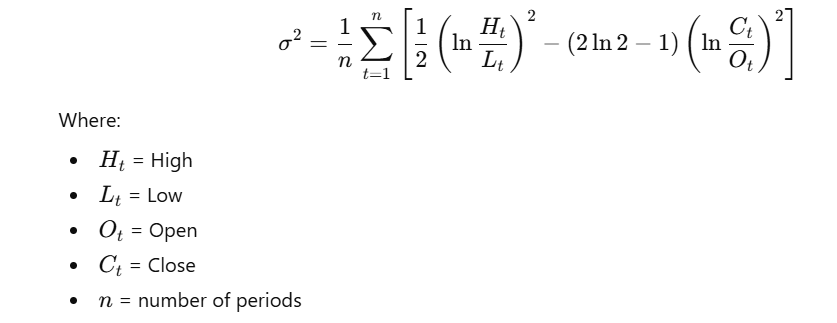


### 2. **RSI (Relative Strength Index)**



```
Imagine you have a toy car that moves on a road. 🚗

Sometimes the car goes up a hill and sometimes it goes down a hill.

Now imagine you are a little robot that watches the car and counts:

- How many times it went up ⬆️

- How many times it went down ⬇️

What RSI Does

RSI (Relative Strength Index) is like a score that tells us:

👉 “Has the car been going up too much or down too much lately?”

The Score

The robot gives a number from 0 to 100.

- Above 70 → The car went up a lot. Maybe it is tired and might go down soon. 😅

- Below 30 → The car went down a lot. Maybe it is ready to go up again. 🚀

- Around 50 → The car is just moving normally.

Kid Version 🧸
Think of RSI like a mood meter for prices:

- Very happy (high number) → went up a lot

- Very sad (low number) → went down a lot

- In the middle → calm

Traders use RSI to guess if a price might rest and turn around soon.
```



- Type: Momentum oscillator -measures how strong recent price gains are relative to recent losses.
- Range: 0–100
- Default period: 14

- What it measures:
    - Speed and magnitude of recent price changes.

- Key levels:

    - Above 70 → Overbought (possible pullback)

    - Below 30 → Oversold (possible bounce)

    - Around 50 → Neutral momentum

- What it tells you:

    - Whether buying or selling pressure is dominant

    - Potential reversal zones

    - Divergences (price makes new high, RSI doesn’t) - Divergence happens when price and RSI move in opposite directions.

- Best for short- to medium-term momentum analysis.

- What RSI Measures

    - It compares:

      - Average recent gains vs. average recent losses

    - If gains dominate → RSI rises
    - If losses dominate → RSI falls

- Limitations: RSI can remain overbought or oversold for extended periods during strong trends and is best used alongside other indicators

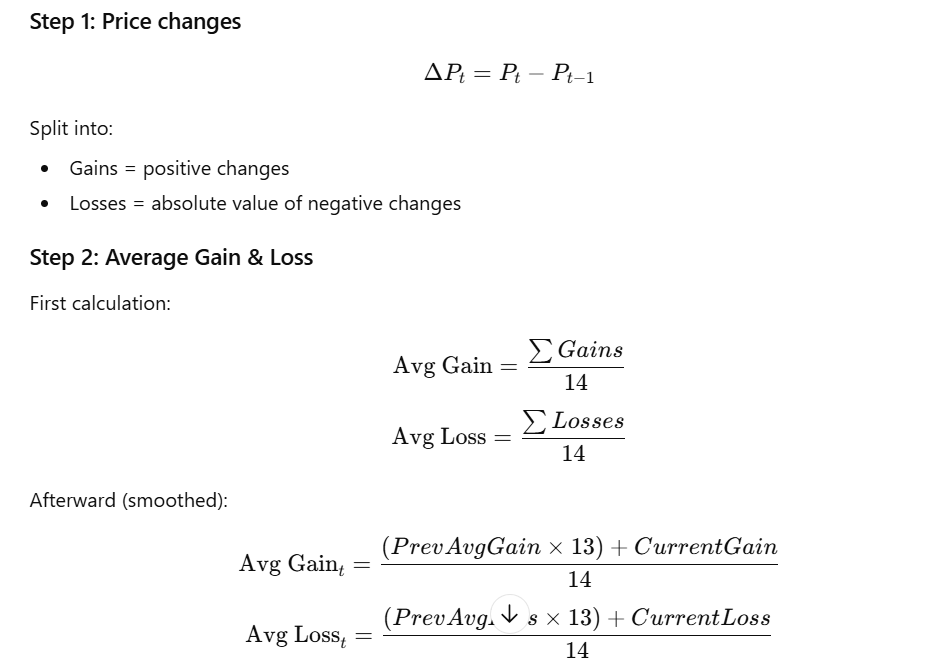


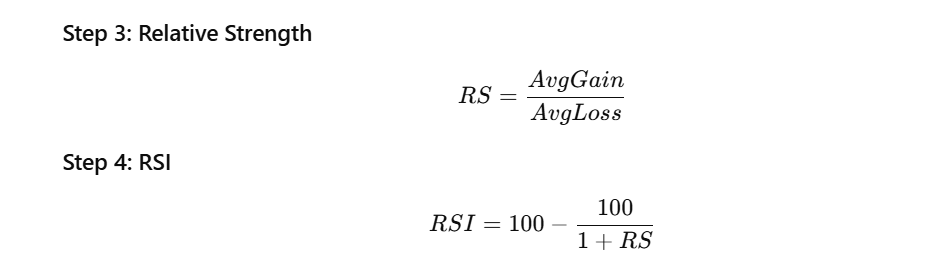

What Is **Divergence**?



```
Example:
Imagine you have:

🚗 A car (this is the price)

⛽ The gas pedal power (this is the RSI / momentum)

Normal Situation

- When you press the gas harder:

  - The car goes faster.

- When you press less:

  - The car slows down.

- Everything matches. 👍

What Is Divergence?

- Divergence is when:

  - The car keeps going faster…
    - But you're actually pressing the gas less.

  - That’s weird, right?

    - It means: ⚠️ The car might slow down soon.

**Bearish Divergence (Going Down Soon)**

- The car goes to a new top speed

    - But your foot is pressing the gas less than before

- So even though it looks fast…

- It’s actually getting tired.

- The car may slow down soon.

**Bullish Divergence (Going Up Soon)**

- The car goes to a new low speed

  - But now you're pressing the gas harder

- Even though it looks slow…

- It’s actually getting stronger.

- The car may speed up soon.

So divergence just means:

- “The outside looks strong, but the inside power is getting weak.

```



- Divergence happens when price and RSI move in opposite directions.

- It signals:

    - Momentum is weakening, even if price is still moving in the same direction.

- This often happens before reversals.

**Bearish Divergence (Most Common)**
- Structure:

    - Price makes a higher high

    - RSI makes a lower high

- What it means:

    - Buyers pushed price higher, but momentum weakened.

- In simple terms:

    - Price went higher… but with less strength.

- This often signals a potential downward reversal.

**Bullish Divergence**
- Structure:

    - Price makes a lower low

    - RSI makes a higher low

- What it means:

    - Sellers pushed price lower, but selling momentum weakened.

- In simple terms:

    - Price fell lower… but with less downside force.

- This often signals a potential upward reversal.

**Types of Divergence**
1. Regular Divergence

- Signals reversal

    - Bullish → possible upward reversal

    - Bearish → possible downward reversal

2. Hidden Divergence

- Signals trend continuation

    - Bullish hidden: Higher low in price, lower low in RSI

    - Bearish hidden: Lower high in price, higher high in RSI


Note: Divergence ≠ Immediate Reversal

Divergence means:

⚠️ “Momentum weakening”
❌ NOT “reverse right now”

Price can continue trending for a while before turning.

Divergence is a warning, not a signal by itself.

Best confirmation:

- Break of support/resistance

- Trendline break

- Volume shift

- Candlestick confirmation

**When Divergence Is Strongest**

✔ Happens near support/resistance
✔ Occurs in overbought/oversold zones
✔ Appears on higher timeframes (4H, Daily)
✔ Confirmed with volume



**How is Divergence Calculated?**
Just compare price swings with RSI swings.
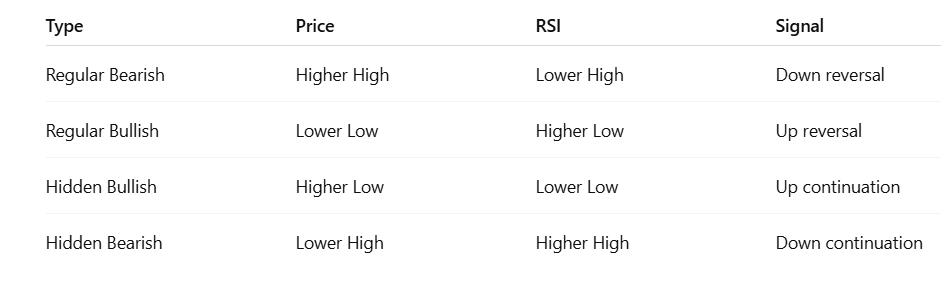

Memory Trick:

- Regular = Reversal

- Hidden = Continuation

- Always compare high with high, low with low

How To Check It Correctly

1. Always compare matching points (high to high, low to low)

2. Use clear swing points (not tiny noise candles)

3. Check if RSI is in extreme zone (above 70 or below 30 = stronger)

4. Confirm with structure break (don’t trade divergence alone)


**Structure Break** (Break of Structure – BOS)

- A structure break happens when price breaks a previous swing high or swing low, changing the market’s pattern.

- It tells you:

    - “The trend might be changing.”

- What Is Market Structure?

    - In an uptrend, price makes:

        - Higher High (HH)

        - Higher Low (HL)

    - In a downtrend, price makes:

      - Lower High (LH)

      - Lower Low (LL)

That pattern is called market structure.

**Break of Structure in an Uptrend (Bearish Signal)**
- Uptrend pattern:
    - HH → HL → HH → HL

- If price suddenly breaks below the last Higher Low (HL):

  ➡ Structure is broken
  ➡ Possible shift to downtrend

This is a bearish structure break.

**Break of Structure in a Downtrend (Bullish Signal)**

- Downtrend pattern:
    - LL → LH → LL → LH

- If price breaks above the last Lower High (LH):

  ➡ Structure is broken
  ➡ Possible shift to uptrend

This is a bullish structure break.

**Why It Matters With Divergence**

- Divergence = warning
- Structure break = confirmation

- Example:
    - Bearish divergence appears

    - Then price breaks previous higher low

    - That confirms weakness

Note: A structure break is: When price breaks the previous swing level that was holding the trend together.

**Confirmation tools**

1️. **Break of Support / Resistance**

```
Example:
(Like a wall breaking)

Imagine a ball keeps bouncing on the floor.

- The floor is support.

- The ceiling is resistance.

If the ball suddenly breaks through the floor, something changed!

That means:
👉 The floor wasn’t strong anymore.

If it breaks through the ceiling:
👉 The ceiling wasn’t strong anymore.

When a wall breaks, it’s serious.
```





- Support

  - A price level where price previously stopped falling.

- Resistance

  - A price level where price previously stopped rising.

- Why it confirms:

  - If price breaks support after bearish divergence, it shows sellers are now stronger.

  - If price breaks resistance after bullish divergence, buyers are taking control.

👉 The break shows real strength — not just indicator weakness.

2. **Trendline Break**


```
(Like walking on a line)

Imagine you’re walking on a straight line.

If you suddenly step off the line…

Something changed, right?

That’s a trendline break.

It means:
👉 The direction you were walking might change.
```



- A trendline connects:

    - Higher lows in an uptrend

    - Lower highs in a downtrend

- Why it confirms:

    - If divergence appears and price breaks the trendline, it signals momentum shift.

- Example:

    - Bearish divergence

    - Uptrend line breaks
      → Higher probability of reversal

- Trendline break = loss of trend control.

3. **Volume Shift**



```
(How loud the kids are shouting)

If only one kid is shouting, it’s quiet.

If ALL kids shout together, it’s loud!

Volume is how loud the market is.

Big loud move = strong
Quiet move = weak

If price moves and everyone is shouting (big volume),
👉 That move is more real.
```



- Volume shows how strong moves are.

- Confirmation signs:

    - For bearish setup:

      - Rising volume on red candles

      - Decreasing volume on green candles

    - For bullish setup:

      - Rising volume on green candles

      - Decreasing volume on red candles

- Strong reversals usually happen with volume expansion.

- Low volume = weak move.


4. **Candlestick Confirmation**



```
(Like body language)

Imagine someone says they’re not angry…

But they stomp their feet and slam the door.

Their body shows the truth!

Candlesticks are like body language.

Big strong candle = strong feeling
Tiny weak candle = not serious
```



- This means waiting for a strong reversal candle.

- Examples:

    - Bearish confirmation:

      - Bearish engulfing

      - Shooting star

      - Strong rejection wick

  - Bullish confirmation:

    - Bullish engulfing

    - Hammer

    - Strong rejection from support

- Candles show real-time battle outcome between buyers and sellers.

**Why You Need Confirmation**

- Divergence = Warning
- Confirmation = Execution signal

- Without confirmation:
❌ You may enter too early
❌ Trend may continue

- With confirmation:
✅ Higher probability
✅ Better timing

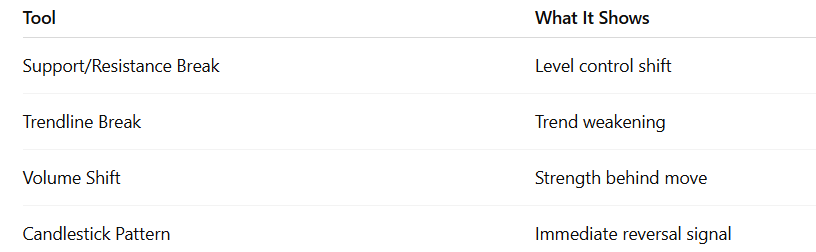

### 3. **Bollinger Bands**

- Bollinger Bands show you: Is price high or low compared to its recent average?


- Measure market volatility and identify potential overbought or oversold conditions. They consist of three lines: a central 20-period simple moving average (SMA), an upper band, and a lower band .


- Components:

1. Middle band → Moving Average (usually 20-period)

2. Upper band → MA + 2 standard deviations

3. Lower band → MA − 2 standard deviations

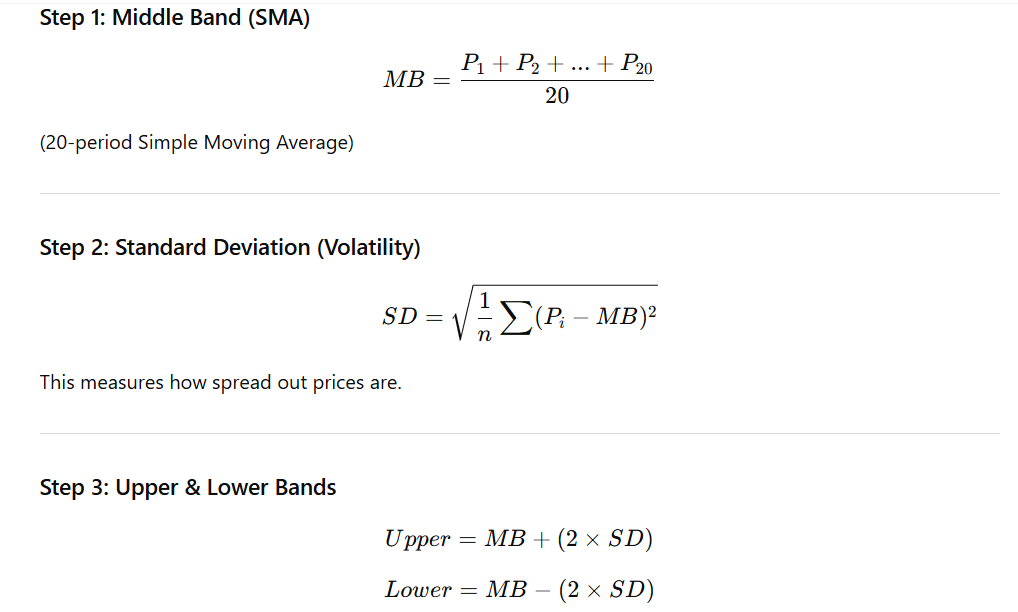

- Default:

  - Period = 20

  - Multiplier = 2


- Key signals:

  - Price near upper band → Potential overextension - Price is relatively high.

  - Price near lower band → Potential oversold - Price is relatively low.

- Band squeeze (When bands get very tight) → Low volatility, possible breakout coming

- Bands expanding → Volatility increasing

- How Traders Use It

1. Mean Reversion

    - Sell near upper band

    - Buy near lower band

2. Breakout Trading

    - Tight squeeze

    - Wait for strong breakout

- Simple Intuition

    - Wide bands → Market is wild

    - Tight bands → Market is calm

    - Price hugging band → Strong trend

Note: rice touching a band does NOT mean reversal. In strong trends: Price can “walk the band” for a long time.



```
Imagine price is like a little kid running around.

Now imagine we put two soft pillows around the kid:

- One pillow on top

- One pillow on the bottom

- These pillows are Bollinger Bands.

🧸 The Middle Line

In the middle, there’s a straight line.

That line is like the kid’s “normal walking path.”

Most of the time, the kid stays near that line.

🟣 The Top Pillow

If the kid jumps and touches the top pillow:

👉 Wow! The kid is very high right now!

That means price is high compared to normal.

🟢 The Bottom Pillow

If the kid touches the bottom pillow:

👉 The kid is very low right now!

That means price is low compared to normal.

😮 When the Pillows Get Close

Sometimes the pillows move very close together.

That means:

👉 The kid is being very calm.

But guess what?

When kids are calm for too long…

They suddenly run very fast! 🏃💨

So tight pillows mean:
A big move might come soon.

😵 When the Pillows Get Far Apart

If the pillows move far away:

👉 The kid is running crazy!

That means the market is very wild.

```



### 4. **ATR (Average True Range)**


```
Imagine you’re watching a dog play every day.

Some days:

- The dog runs A LOT 🐕💨

- Very wild and fast!

Some days:

- The dog barely moves 🐶

- Very calm.

ATR just measures:

- How much the dog moves each day.

It does NOT care if the dog runs left or right.

It only cares:

👉 “How big was the movement?”
```



- Average True Range (ATR) measures market volatility by calculating the average range of price movement (high to low) over a specified period, usually 14 days.

- It measures: How much price moves on average per candle.

- It does NOT show direction. It only shows volatility.

- If ATR increases:
👉 Market is getting more volatile.

- If ATR decreases:
👉 Market is calming down.

- Why Traders Use ATR

1️⃣ To set stop losses
Example:
Stop = Entry − (2 × ATR)

2️⃣ To size positions
Bigger ATR → smaller position
Smaller ATR → bigger position

3️⃣ To detect breakout conditions
Volatility expansion often follows low ATR.

- If ATR = 2: Price moves about $2 per candle (on average).

Note: ATR answers one question: “How big are the candles lately?”
Not: Not “up or down”. Just “how big”.

## **Position**

- A position means: A trade that you have opened. It simply means you are in the market.

- Long Position: You buy something because you think price will go up.

    - Example:

      - You buy at $100

      - Price goes to $110

    - You make money

    - That is a long position.

- Short Position: You sell because you think price will go down.

  - Example:

    - You sell at $100

    - Price drops to $90

  - You make money

  - That is a short position.

- Position size = how much you buy or sell.

  - Example:

    - Buying 1 share = small position

    - Buying 1,000 shares = big position



### 5. **MACD (Moving Average Convergence Divergence)**



```
Imagine you and your friend are running 🏃🏃‍♂️

You are the fast runner

Your friend is the slow runner

Now we watch:

👉 How far ahead you are from your friend.

That distance is MACD.

🟢 If the fast runner runs much faster

The distance gets bigger.

That means:
👉 Things are speeding up!

(Big momentum)

🔴 If the fast runner slows down

The distance gets smaller.

That means:
👉 Things are slowing down.

(Momentum getting weak)

✨ When the fast runner crosses in front

That’s like a signal saying:

👉 “Now we’re going up!”

If the fast runner falls behind:

👉 “Now we’re going down!”
🎨 The Little Bars (Histogram)

Imagine drawing bars to show how far apart the runners are.

Big bars = big speed difference
Small bars = little speed difference

Super Simple Idea

MACD just tells us:

“Is the fast runner pulling away or getting tired?”
```




- MACD is a trend + momentum indicator.

- It helps answer two questions:

    - Is the trend bullish or bearish?

    - Is momentum getting stronger or weaker?

- Components:

1. MACD Line → 12 EMA − 26 EMA

2. Signal Line → 9 EMA of MACD

3. Histogram → Distance between MACD and Signal

- What it measures:
Trend strength and momentum.

- Key signals:

    - MACD crosses above Signal → Bullish

    - MACD crosses below Signal → Bearish

    - Zero Line

      - When MACD crosses above 0:
        
        → Short-term average is above long-term average (bullish trend)

      - When MACD crosses below 0:
          
          → Bearish trend


- What the Histogram Shows

  - Growing bars → Momentum increasing

  - Shrinking bars → Momentum weakening

  - Cross from negative to positive → Bullish shift

  - Cross from positive to negative → Bearish shift


Note: MACD works best:
  - In trending markets
  - On higher timeframes

It is weaker in sideways markets.

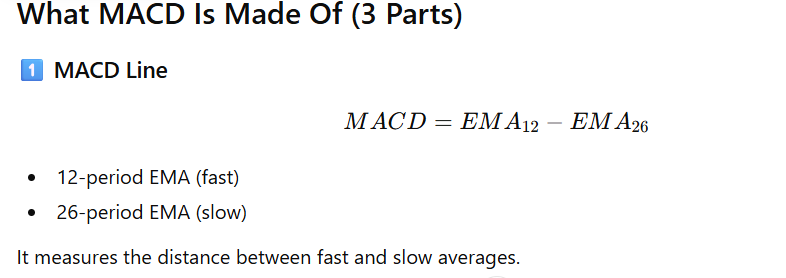

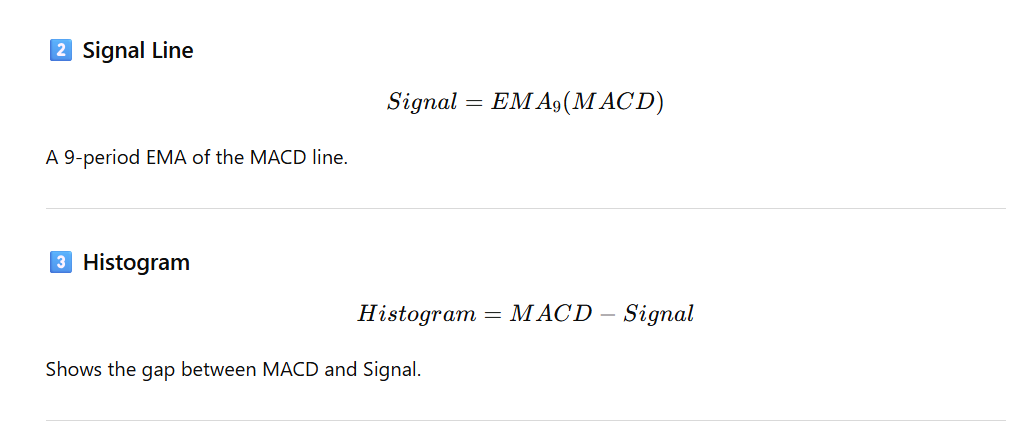





### **EMA (Exponential Moving Average)**

- EMA is a type of moving average.

- It shows the average price, but:

    It gives more importance to recent prices.



```
Imagine you ask 10 kids what their favorite color is.

But you care more about what the kids said today than what they said last week.

So you listen more carefully to the newest answers.

That’s EMA.

It cares more about recent prices.
```

- Recent prices matter more.

- That makes EMA:

    - Faster

    - More responsive

    - React quicker to price changes

- Why Traders Use EMA

    - Detect trends

    - Identify dynamic support/resistance

    - Used inside indicators like MACD

- Simple Intuition

    - SMA = Slow and smooth
    - EMA = Faster and reacts quickly

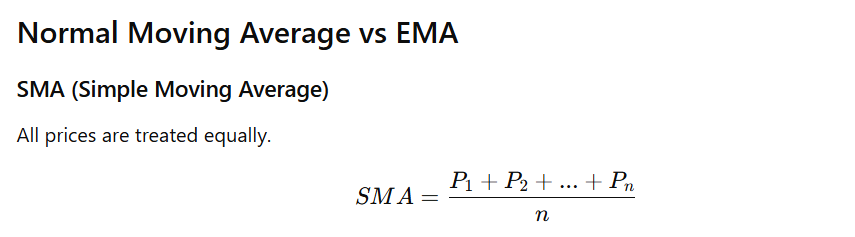

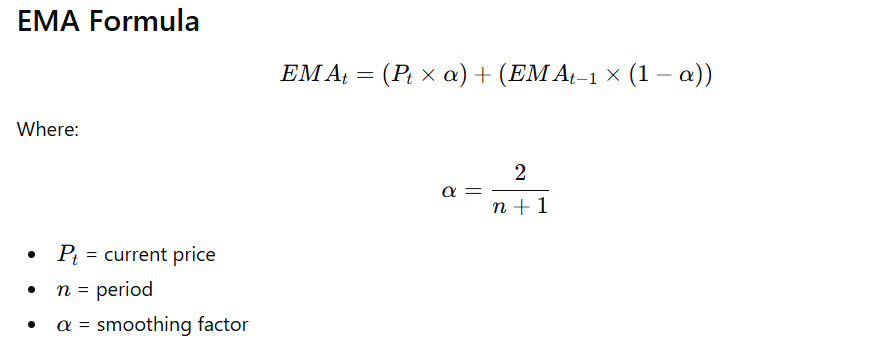

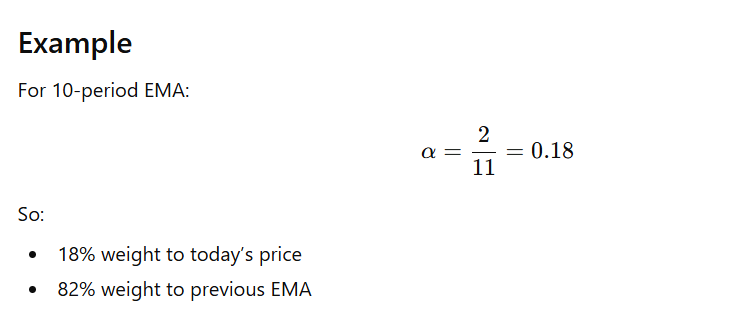



### 6. **Dollar Volume**

- Dollar Volume tells you:

    How much money was traded in a stock (or asset) during a period.

- It measures liquidity.

- Dollar Volume is the total monetary value of an asset traded over a specific period, calculated by multiplying the number of shares traded by their price.

- It serves as a key liquidity metric for investors to assess how easily a stock can be bought or sold.


```
Imagine:

10 toys were sold

Each toy costs $5

How much money was used?

10×5=50

So, $50 was traded.

That’s dollar volume.
```


- What it measures:
    Total capital traded during a period.

- It is crucial for institutional investors to determine if a stock has enough liquidity to support large positions without causing significant price impact.

- Unlike market capitalization, which indicates company size, dollar volume measures trading activity.

- Why It Matters

  - High Dollar Volume:

    - Easy to buy and sell

    - Big traders are involved

    - Less slippage

  - Low Dollar Volume:

    - Harder to enter/exit

    - Price can move suddenly

    - Riskier

- Important Difference

  - Volume = number of shares
  - Dollar Volume = total money traded

  - Two stocks can have same volume but different dollar volume if prices differ.


- Common in:
    - Quantitative screening

    - Liquidity filters

    - Momentum strategies

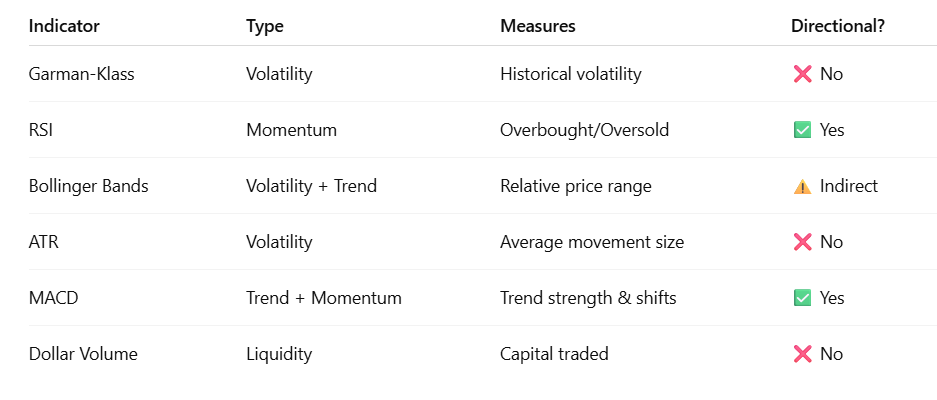

In [ ]:
#print(df.head)
print(df.columns)


df['garman_klass_vol']=((np.log(df['high'])-np.log(df['low']))**2)/2-(2*np.log(2)-1)*((np.log(df['adj close'])-np.log(df['open']))**2)
print("After garman_klass_vol:")
print(df[['garman_klass_vol']].head)

df['rsi'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.rsi(close=x, length=20))
# groupby(level=1) groups the DataFrame by the second level of its index (since Python is 0-indexed)
# This is common in multi-index DataFrames, for example, where level 0 could be a date and level 1 could be a stock ticker.
# Each group will contain all rows that share the same value at that index level.
# ['adj close'] - Selects the column 'adj close' from each group - Only the adjusted closing prices are needed to calculate the RSI.
# .transform(lambda x:) - transform applies a function to each group but returns a Series with the same index and same length as the original DataFrame
# pandas_ta.rsi() is from the pandas_ta library, which calculates the Relative Strength Index (RSI).
# close=x tells the function to use the group’s adjusted close prices.
# length=20 sets the RSI period to 20 days (default is usually 14).
# df['rsi'] = Assigns the transformed RSI values back to a new column 'rsi' in the original DataFrame.
# Because transform keeps the original DataFrame’s index, the RSI values line up correctly with each row
print("After RSI:")
print(df[['rsi']].head)


# Compute Bollinger Bands
log_price = np.log1p(df['adj close'])
# np.log1p(x) computes: log(1 + x)

rolling = log_price.groupby(level=1).rolling(14)
# groupby(level=1) - Groups by ticker - So calculations are separate for each stock.
# Creates a 14-period sliding window - So each row gets statistics from the last 14 observations.

# compute rolling mean and std per ticker
mean = rolling.mean().droplevel(0) # Computes: 14-day moving average
std = rolling.std().droplevel(0) # computes volatility over the last 14 periods
# After groupby + rolling, pandas creates a multi-index result: ticker   date   ticker
#                                                      Example: AAPL  2024-01-14  AAPL
# .droplevel(0) removes the extra groupby level so the index matches your original dataframe.

df['bb_mid'] = mean
df['bb_high'] = mean + 2 * std
df['bb_low'] = mean - 2 * std

print("After Bollinger Bands calculation:")
print(df[['bb_mid']].head)
print(df[['bb_high']].head)
print(df[['bb_low']].head)

def compute_atr(stock_data):
    atr = pandas_ta.atr(
        high=stock_data['high'],
        low=stock_data['low'],
        close=stock_data['close'],
        length=14
    )

    if atr is None: # prevents the crash: AttributeError: 'NoneType' object has no attribute 'sub' , Returns an empty series with NaNs aligned to the original index.
        return pd.Series(index=stock_data.index, dtype="float64")

    return (atr - atr.mean()) / atr.std() # converts ATR into a z-score.
#Calculates ATR (Average True Range) over 14 periods.
# Computes mean and standard deviation of the ATR series.
# Normalizes ATR: 𝑧=(𝐴TR−𝜇)/𝜎
# positive value → higher than normal volatility
# negative value → lower than normal volatility
# This is useful for volatility-based trading signals.

df['atr'] = df.groupby(level=1, group_keys=False).apply(compute_atr)
# level=1 is the ticker/symbol level
# group_keys=True → “Attach the group name to the result index”
# group_keys=False → “Just give me the data back clean” - Keeps the original index structure.
# .apply(compute_atr) - Computes For each ticker


print("After ATR calculation:")
print(df[['atr']].head)

def compute_macd(close):
  # Ensures there are at least 30 data points; otherwise, MACD computation might fail or be unreliable.
  # If not enough data, returns an empty Series with the same index as close.
    if len(close) < 30: # avoids the error: AttributeError: 'NoneType' object has no attribute 'iloc'
        return pd.Series(index=close.index, dtype=float)

    macd = pandas_ta.macd(close=close, length=20).iloc[:,0]
    return (macd - macd.mean()) / macd.std()

df['macd'] = df.groupby(level=1, group_keys=False)['adj close'].apply(compute_macd)
print("After MACD calculation:")
print(df['macd'].head)

df['dollar_volume'] = (df['adj close']*df['volume'])/1e6
print("After Dollar Volume caluclation:")
print(df['dollar_volume'].head)

df.head(50)


### 3. **Aggregate to monthly level and filter top 150 most liquid stocks for each month.**



To reduce training time and experiment with features and strategies, we convert the business-daily data to month-end frequency.

Convert daily stock data into one observation per stock per month, and for each month keep only the 150 stocks with the highest trading liquidity to reduce dataset size and improve practicality.

Explanation:

1️⃣ “Aggregate to monthly level”
If your original data is business-daily (one row per stock per trading day), aggregating to monthly level means:

- Combine all daily data within each month

- Create one observation per stock per month

- Usually aligned to month-end

👉 So instead of ~252 observations per year per stock, you now have 12.

This dramatically reduces:

- Dataset size

- Training time

- Noise



2️⃣ “Filter top 150 most liquid stocks for each month”

Liquidity means how easily a stock can be traded without impacting price.

Common liquidity measures:

- Average daily volume

- Dollar trading volume (price × volume)

- Bid-ask spread (if available)

What this step means:

For each month:

1. Rank all stocks by liquidity

2. Select the top 150 most liquid

3. Keep only those for modeling

So the stock universe may change each month.







In [ ]:
last_cols = [c for c in df.columns.unique(0) if c not in ['dollar_volume', 'volume', 'open',
                                                          'high', 'low', 'close']]
# selects all columns EXCEPT price and volume-related columns.
# Unique feature names


# multi-index time-series feature engineering pipeline
data = (pd.concat([df.unstack('ticker')['dollar_volume'].resample('ME').mean().stack('ticker').to_frame('dollar_volume'),
                   df.unstack()[last_cols].resample('ME').last().stack('ticker')],
                  axis=1)).dropna()
# .resample('ME') means resample the time series to Month-End frequency
# .to_frame('dollar_volume') - Ensures the result is a DataFrame instead of Series
# data = (
#     pd.concat([...], axis=1)
# ).dropna()
# Two datasets are created and then concatenated column-wise.
# axis=1 → join side-by-side
# .dropna() → remove rows where any value is missing
# So the result is a clean monthly dataframe per ticker.

# 1. Converts daily data into monthly data
# 2. Computes: Monthly average dollar volume, Month-end values for other features
# 3. Combines them back together
# 4. Drops missing rows

# Resampling = converting time-series data to a different time interval (daily → monthly, hourly → daily, etc.) using aggregation.

# So:
    # All days in January → averaged
    # All days in February → averaged
    # etc.
# Now index = month-end date

# why are we handling dollar volume separately instead of treating it like the other indicators?
# dollar_volume measures liquidity:
# Liquidity is meaningful as:
  # Average liquidity over the month
  # Not just liquidity on the last day
  # If you used .last():
  # You would only get liquidity from the final trading day
  # That could be unusually high/low
  # Not representative of the month

data

**Difference between dataframe and series**
In pandas, the two core data structures are Series and DataFrame. The easiest way to think about them is:

1. Series → 1-dimensional labeled array

2. DataFrame → 2-dimensional labeled table

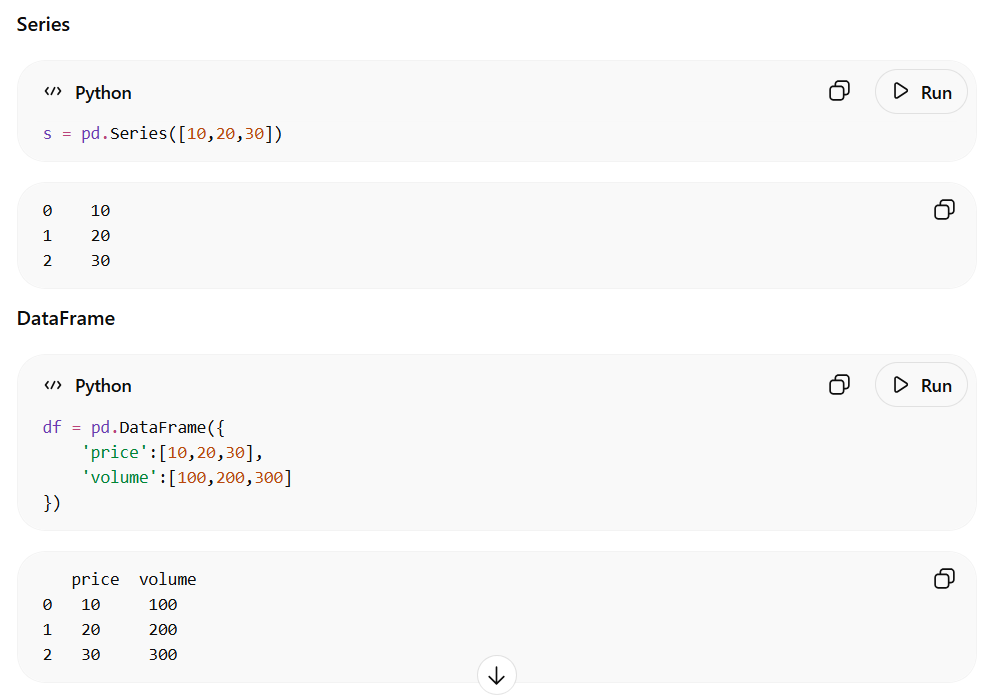

Note: A DataFrame is basically a collection of Series.

Note: In pandas, **axis** tells the function which direction to operate on.

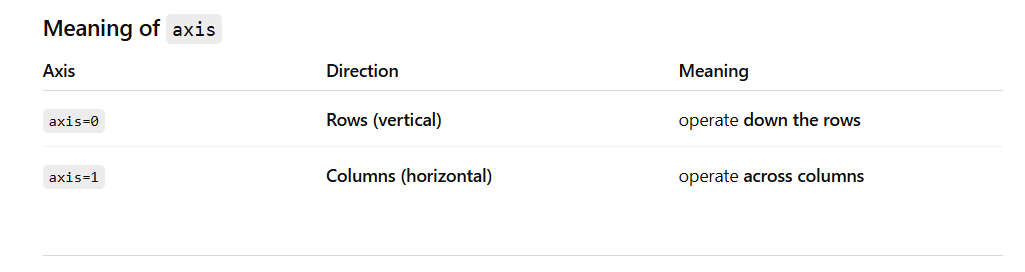



Calculate 5-year rolling average of dollar volume for each stocks before filtering.

For each individual stock:

1. Look backward 5 years

2. Compute the average dollar_volume over that window

3. Do this at every point in time

4. Then use that rolling value later for filtering

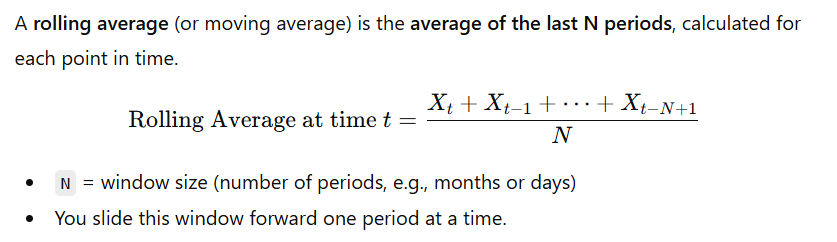



Summary of the whole process:

1. Compute 5-year rolling average dollar volume for each stock.

2. Rank stocks by liquidity on each date.

3. Keep only the top 150 most liquid stocks.

4. Remove intermediate columns to clean up the dataset.

In [ ]:
data['dollar_volume'] = (data.loc[:, 'dollar_volume'].unstack('ticker').rolling(5*12, min_periods=12).mean().stack())
# data.loc[:, 'dollar_volume'] - Extracts the dollar_volume column
# .unstack('ticker') - Transforms the structure - Now each ticker is a column.
# .rolling(5*12, min_periods=12) - creates a sliding window of 60 observations for each ticker
# min_periods=12 means: Need at least 12 observations, Otherwise result = NaN
# .mean() - Computes the rolling average dollar volume
# .stack() - Returns the structure back to MultiIndex format

data['dollar_vol_rank'] = (data.groupby('date')['dollar_volume'].rank(ascending=False))
# Ranks stocks per date. Higher liquidity → lower rank number.

data = data[data['dollar_vol_rank']<150].drop(['dollar_volume', 'dollar_vol_rank'], axis=1)
# Keep Only Top 150 Liquid Stocks - This removes illiquid stocks.
# Low liquidity causes: large spreads, slippage, unreliable signals
# Removes helper columns used for filtering. Remaining dataset keeps only original features.


data

## **4**. **Calculate Monthly Returns for different time horizons as features.**

To capture time series dynamics that reflect, for example, momentum patterns, we compute historical returns using the method .pct_change(lag), that is, returns over various monthly periods as identified by lags.


A **return** measures how much the price of an asset (like a stock) has changed over a period. In pandas, this is calculated using: pct_change()

It returns the percentage change between two values.

Formula:
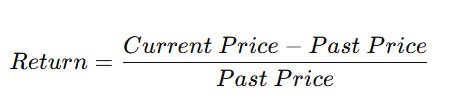

Instead of only calculating 1-month return, we calculate returns over multiple past periods such as:

- 1-month return

- 3-month return

- 6-month return

- 12-month return

These are called lags.

They represent different time horizons of past performance.

These returns are used as features in machine learning models.

They help capture time-series dynamics, such as:

**Momentum**

Assets that performed well recently may continue performing well.

Example signals:

- High 3-month return

- High 6-month return

Model may interpret this as positive momentum.

**Reversal**

Sometimes assets that rose a lot may fall later.

Models can learn these patterns from historical returns.

✅ In simple words:

The step means:

Calculate percentage price changes over different past months (1, 3, 6, etc.) using .pct_change(lag) so the model can learn patterns like momentum from historical performance.



In [ ]:
# g = df.xs('ADANIPORTS.NS', Level=1)
# It filters the DataFrame to only rows where the second index level equals 'ADANIPORTS.NS'


# Each df passed here is one group of data (likely one stock/ticker)
def calculate_returns(df):

    outlier_cutoff = 0.005
    #So returns will be clipped between: 0.5th percentile and 99.5th percentile

    lags = [1, 2, 3, 6, 9, 12] # These represent months of lookback

    for lag in lags: # For each lag, a new column is created.

        df[f'return_{lag}m'] = (df['adj close']
                              .pct_change(lag) # Calculate lagged percentage return
                              .pipe(lambda x: x.clip(lower=x.quantile(outlier_cutoff), # Clip extreme returns - removes extreme outliers - Extreme values can distort models
                                                     upper=x.quantile(1-outlier_cutoff)))
                              .add(1) # convert return to growth factor
                              .pow(1/lag) # Converts lag return → average monthly return
                              .sub(1)) # convert back to return
        # So the final result is average monthly return over the lag period
    return df


data = data.groupby(level=1, group_keys=False).apply(calculate_returns).dropna()
# This means: Data is grouped by index level 1, Likely ticker symbols
# .dropna() - Remove rows with NaN
# group_keys=False tells pandas: “Do not insert the group labels into the result index when using apply()

data

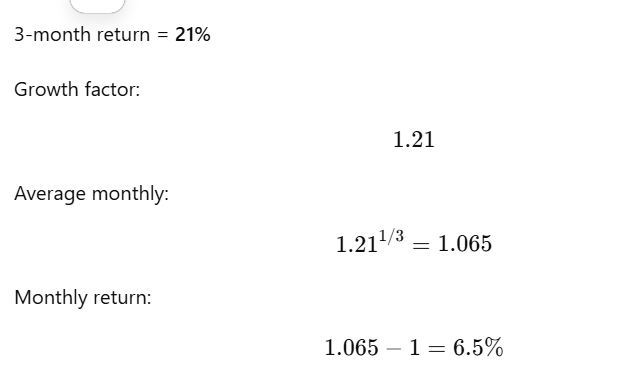

## 5. **Download Fama-French Factors and Calculate Rolling Factor Betas.**

- We will introduce the Fama—French data to estimate the exposure of assets to common risk factors using linear regression.

- The five Fama—French factors, namely market risk, size, value, operating profitability, and investment have been shown empirically to explain asset returns and are commonly used to assess the risk/return profile of portfolios. Hence, it is natural to include past factor exposures as financial features in models.

- We can access the historical factor returns using the pandas-datareader and estimate historical exposures using the RollingOLS rolling linear regression.



What are **Fama–French Factors**?



```
Imagine you and your friends are playing a game where you pick trees that grow apples 🍎. Some trees give more apples, some give less. Two smart professors, Eugene F. Fama and Kenneth R. French, tried to understand why some trees give more apples than others.

In the real world, the “trees” are companies, and the “apples” are money people earn from stocks.

They found that five simple things often explain why some stocks give more money.

🌎 1. The Whole Market Mood

If almost all companies are doing well, most stocks go up.

Think of it like:
If it’s a sunny day, most trees grow nicely.

So this factor checks:
👉 Is the whole market having a good day or bad day?

(This idea comes from a famous model called the Capital Asset Pricing Model.)

🌱 2. Small Trees vs Big Trees

Sometimes small companies grow faster than big companies.

Like:

Small young tree 🌱 → grows quickly

Big old tree 🌳 → grows slowly

So the model checks:
👉 Are small companies doing better than big ones?

This is called SMB (Small Minus Big).

📚 3. Cheap Companies vs Popular Companies

Some companies are cheap but strong, while others are very popular and expensive.

Think of toys:

A cheap toy that works great 🧸

A super famous expensive toy

Often the cheap good one surprises everyone.

This factor checks that difference.
It’s called HML (High Minus Low).

💪 4. Strong Companies vs Weak Companies

Some companies make a lot of profit, others make very little.

Like:

Strong kid 💪 lifting heavy blocks

Tired kid 😴 lifting small blocks

Stronger companies often do better.

🐢 5. Careful Companies vs Spend-a-Lot Companies

Some companies are careful with money, others spend a lot trying to grow.

Like:

Kid who saves candy 🍬

Kid who eats all candy immediately

Sometimes the careful ones do better.

✅ Simple idea:

These five things help explain why some stocks give more money:

1. How the whole market is doing

2. Small vs big companies

3. Cheap vs expensive companies

4. Strong profit vs weak profit

5. Careful spending vs aggressive spending

So the Fama–French model is basically a smart checklist for why some stocks grow more than others. 📈
```



The Fama–French Five-Factor Model is a financial model that explains stock returns using five systematic risk factors instead of only the market.

The five factors are:

1. Market Risk (MKT-RF):

- The excess return of the stock market over the risk-free rate.

- Captures overall market movement.

- Interpretation:
    Stocks with higher sensitivity to market movements have higher expected returns.

    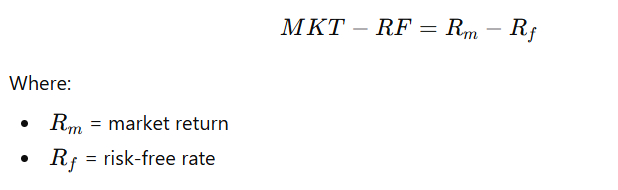

2. Size (SMB – Small Minus Big)

- Measures the performance difference between small-cap and large-cap stocks.

- Insight: Historically, small companies outperform large companies on average.

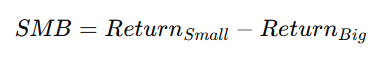


3. Value (HML – High Minus Low)

- Compares value stocks (high book-to-market) vs growth stocks.

- Insight: Value stocks historically outperform growth stocks.

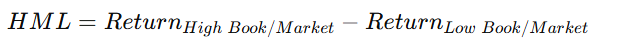

4. Operating Profitability (RMW – Robust Minus Weak)

- Firms with high profitability tend to outperform less profitable firms.

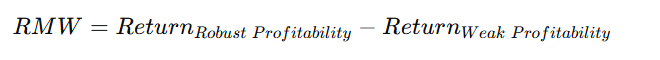


5. Investment (CMA – Conservative Minus Aggressive)

- Firms that invest conservatively tend to outperform firms that invest aggressively.

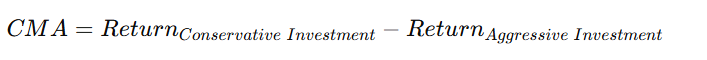

These factors were developed by economists Eugene Fama and Kenneth French.

Why the Model Is Important

Used in:

- Portfolio management

- Asset pricing research

- Performance evaluation of mutual funds

- Factor investing strategies

Large institutions like BlackRock and Vanguard Group use factor models when building investment strategies.

Note: The Fama–French model says stock returns are driven by multiple systematic risk factors, not just market risk.

Why Are These Factors Used?

Instead of just saying:

“This stock performed well.”

The model tries to answer:

- Did it perform well because the market went up?

- Because it behaves like small-cap stocks?

- Because it behaves like value stocks?

So the model explains returns using risk exposures.

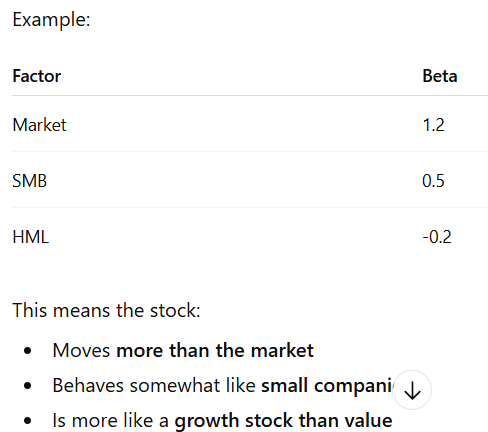

### **Factor Exposure (Beta)**

Factor exposure, usually called Beta (β), measures how sensitive a stock or portfolio is to a particular risk factor.

In factor models like the Fama–French Five-Factor Model, beta tells us how much an asset's return changes when a factor changes.



```
Imagine you have a toy boat in water 🚤.

Sometimes the water moves because of different things:

Wind 🌬️

Waves 🌊

Big boats passing 🚢

Rain 🌧️

Your little boat moves because of these forces.

Now think of a stock like that toy boat 📈

The stock price moves because of different forces in the market.

For example:

The whole market going up or down

Small companies doing well

Value companies doing well

These forces are called factors.

What is Beta (Factor Exposure)?

Beta tells us how strongly the boat moves when the water moves.

Example:

If a big wave comes 🌊

Boat A moves a lot

Boat B moves a little

So we say:

Boat A has big beta

Boat B has small beta

Simple Example

If the market goes up 1 step:

Stock A goes up 1 step → Beta = 1

Stock B goes up 2 steps → Beta = 2

Stock C goes up half a step → Beta = 0.5

So beta just tells how strongly something reacts.

✅ Super simple definition

Factor Exposure (Beta) = how much a stock moves when a market force moves.

Like:

"When the water moves, how much does the boat move?" 🚤🌊
```



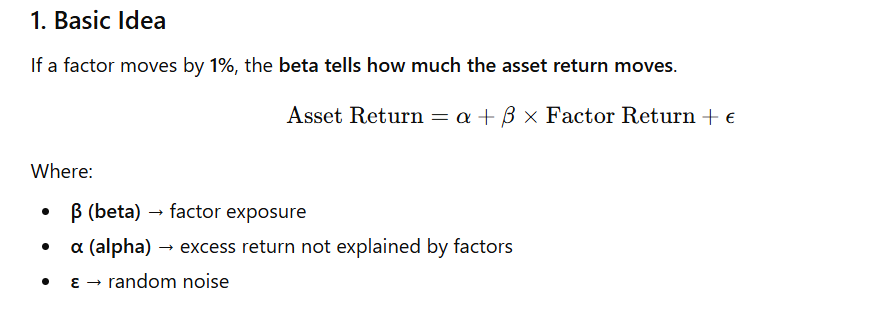


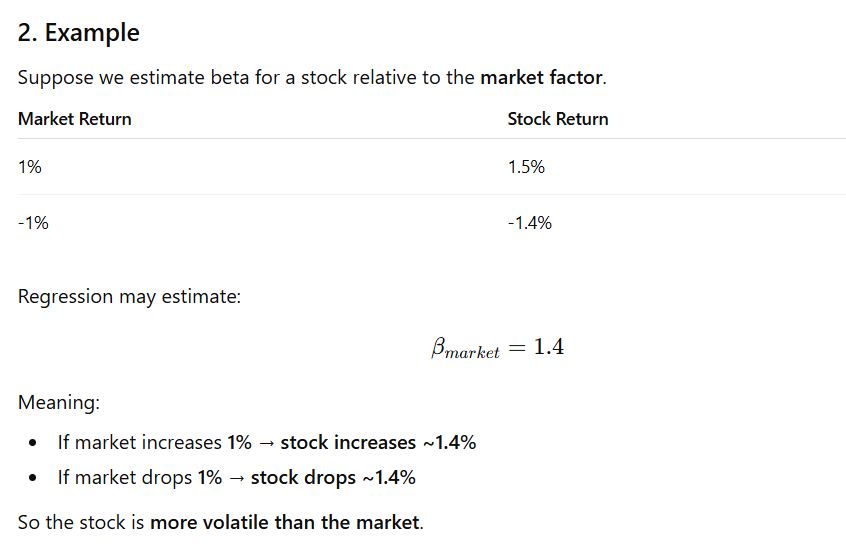


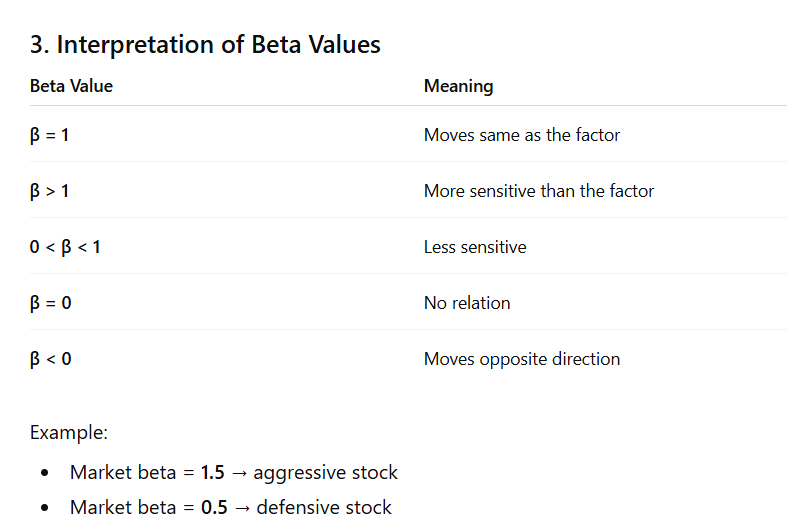

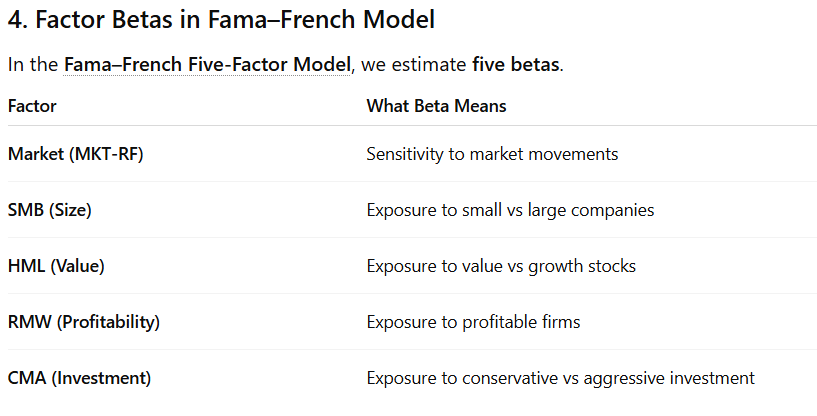

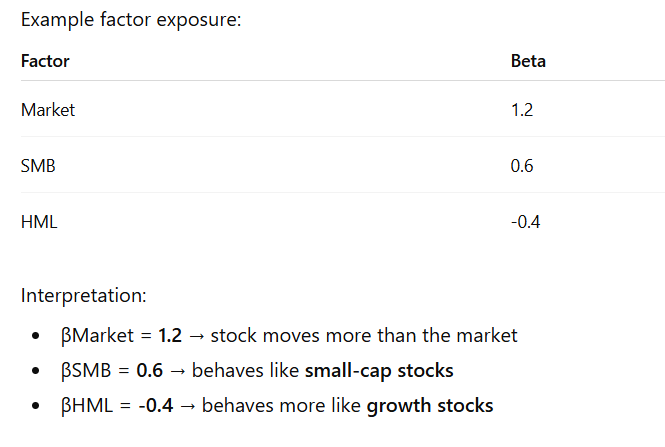

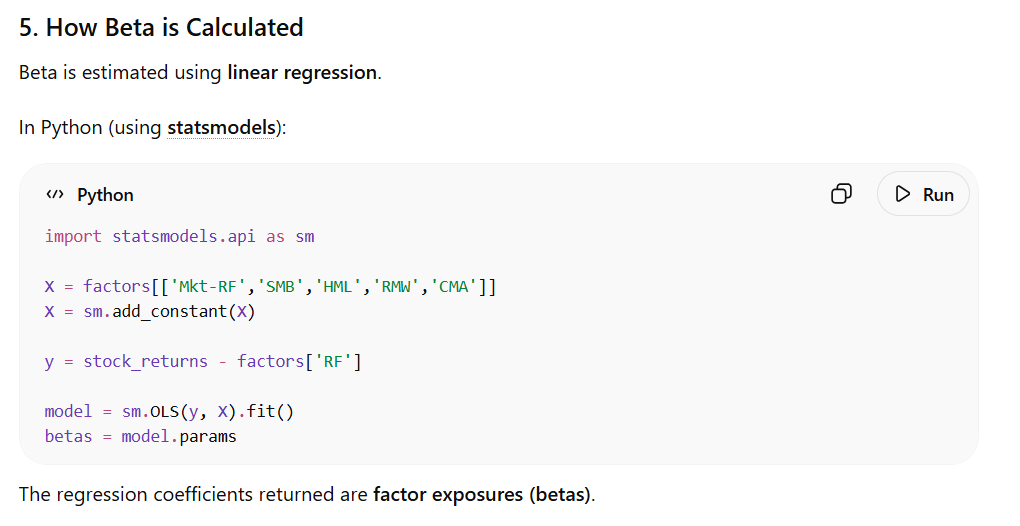

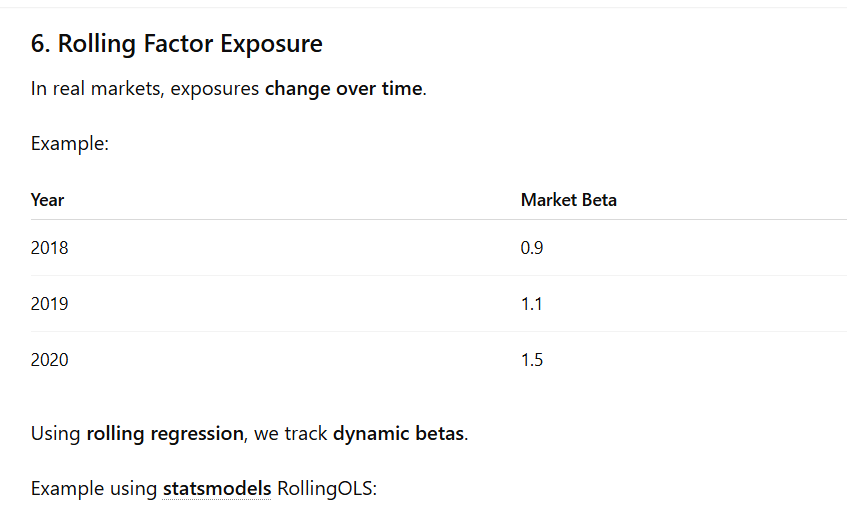


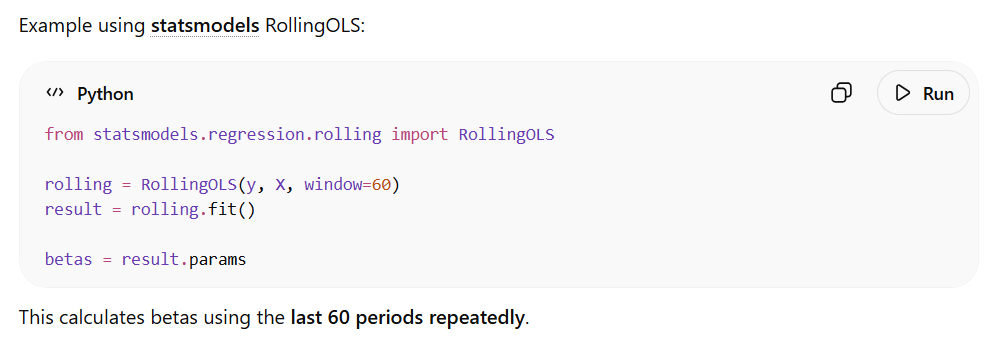


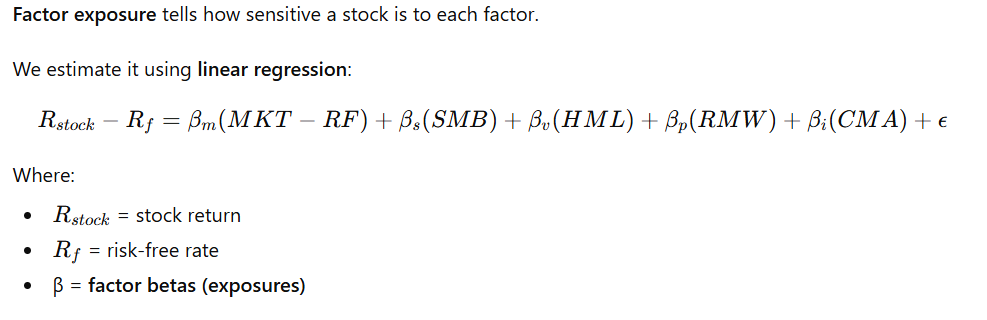

In real markets, factor exposures change over time.

A company may:

- start as a small company

- later become a large company

So we estimate rolling regressions using statsmodels's RollingOLS.

Instead of one regression for the whole dataset, we compute regression on moving windows.

✅ Simple summary

Factor Exposure (Beta) tells:

- How strongly a stock reacts to a particular risk factor.

- Calculated using linear regression

- Used in asset pricing models

- Helps understand risk sources

- Important for portfolio analysis and quantitative finance



## **Value Stocks vs Growth Stocks**


These are two major investment styles used in stock markets. The difference mainly comes down to how the company uses its profits and how investors expect it to grow.



```
Imagine two types of trees in a garden 🌳

🍎 Value Stock (The Old Apple Tree)

This tree is already big and strong.

It gives apples every year 🍎

People know it is good and reliable

Sometimes people forget how good it is, so its price becomes cheap.

So when you buy it:

You get apples regularly (like dividends 💰)

And maybe later people realize “Hey this tree is great!” and the price goes up.

👉 This is like a value stock.

Example grown-up companies like
Coca-Cola are often described this way.

🌱 Growth Stock (The Fast Growing Little Tree)

This tree is still small but growing very fast.

It is not giving many apples yet

But it is getting bigger every year

People think it will become a huge tree later.

So when you buy it:

You wait for the tree to grow big

Later it might be worth a lot more.

👉 This is like a growth stock.

Example fast-growing companies includes tesla and NVIDIA
```



📉 Value Stocks

Value stocks are shares of companies that appear undervalued compared to their true worth.

1. Key characteristics:

- Usually have low P/E (Price-to-Earnings) ratios

- Often pay dividends

- Typically stable, mature companies

- Market may be temporarily underestimating their value

2. Why investors buy them:

- Expect the market to eventually recognize the true value

- Potential for steady returns + dividends

3. Common sectors

- Banking

- Energy

- Manufacturing

- Utilities

4. Example companies often considered value-style:

- Berkshire Hathaway

- JPMorgan Chase

- Coca-Cola

5. Famous value investor:

Warren Buffett

📈 Growth Stocks

Growth stocks are shares of companies expected to grow revenue and profits faster than the overall market.

1. Key characteristics:

- High P/E ratios

- Usually do not pay dividends

- Profits are reinvested into expansion

- Often technology or innovative companies

2. Why investors buy them:

- Expect strong price appreciation

- Willing to accept higher volatility

3. Common sectors

- Technology

- AI

- Biotechnology

- E-commerce

4. Examples of growth companies:

- Tesla

- NVIDIA

- Amazon

5. Investors buy them expecting future earnings to grow rapidly.



✅ Simple way to remember

- Value stock: Cheap today, value realized later

- Growth stock: Expensive today, but growing fast

💡 Pro investor strategy:
Many investors hold both value and growth stocks to balance risk and return.


**Which Performs Better in Different Economic Conditions**
📈 During Inflation

Value stocks usually perform better.

Why:

- Commodity companies benefit from higher prices

- Banks earn higher interest spreads

Examples:

- ONGC

- Coal India

- State Bank of India

Reason:

Oil, metals, banking often benefit from inflation cycles.

📉 During Recession / Slow Economy

Value stocks tend to hold up better because they are cheaper and pay dividends.

But some high-quality growth companies remain strong.

Example defensive growth:

- Tata Consultancy Services

- Infosys

These companies still get global IT contracts.

🚀 During Economic Boom

Growth stocks usually outperform.

Reason:

- Businesses expand quickly

- Earnings growth accelerates

- Investors are willing to pay high valuations

Examples:

- HDFC Bank

- Asian Paints


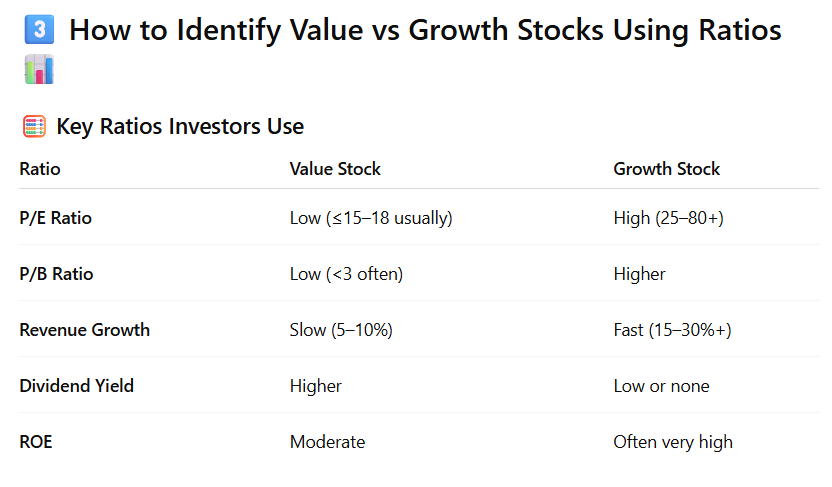







In the stock market, companies are grouped by their size. The size is measured using **Market Capitalization (Market Cap)**.

- Market Cap = Share Price × Total Number of Shares

- In India (as defined by Securities and Exchange Board of India), companies are classified into Large Cap, Mid Cap, and Small Cap.

🏢 Large Cap Stocks

These are the top 100 biggest companies by market value.

Characteristics

- Very stable

- Lower risk

- Slower but steady growth

Examples

- Reliance Industries

- Tata Consultancy Services

- HDFC Bank

Think of them as big elephants 🐘 — strong but move slowly.

🚀 Mid Cap Stocks

These are companies ranked 101–250 by market cap in India.

Characteristics

- Growing businesses

- Moderate risk

- Potential to become future large caps

Examples

- Polycab India

- Lupin

- AU Small Finance Bank

Think of them as young elephants 🐘 growing bigger.

🌱 Small Cap Stocks
4

These are companies ranked 251 and below by market cap.

Characteristics

- Very high growth potential

- Higher risk and volatility

- Less stable than large caps

Examples

- Tanla Platforms

- Rain Industries

Think of them as small plants 🌱 that could grow into big trees.

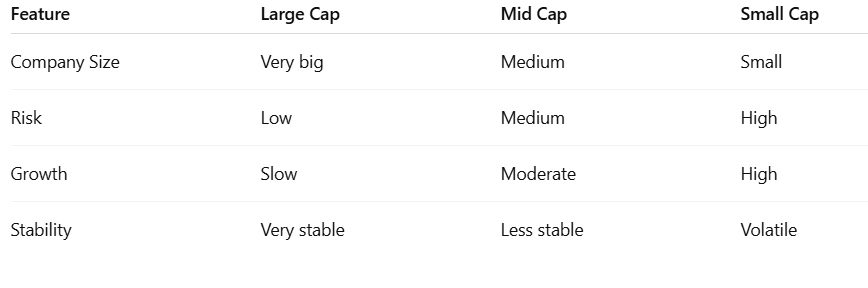


✅ Simple example

If you invest ₹100:

₹50 in Large caps → stability

₹30 in Mid caps → growth

₹20 in Small caps → high potential

This helps balance risk and returns.

This code:

1. Downloads Fama-French factors

2. Combines them with stock returns

3. Runs rolling regression for each stock

4. Calculates time-varying factor betas

5. Adds those betas as features to the dataset

**Why is factor exposure required for designing the trading algo?**

Factor exposure is required for designing trading algorithms because it identifies, measures, and manages the underlying systematic risks driving asset returns, moving beyond simple price-based signals to create more robust, consistent, and diversified strategies. It allows developers to understand why a portfolio is making or losing money and enables the optimization of risk-adjusted returns by balancing exposure to specific factors like Value, Momentum, or Size.


Here is why factor exposure is essential for trading algo design:

1. Risk Management and Hedging: Algorithms often unintentionally take on massive exposures to factors like "Market Beta" or "Sector Risk." By measuring factor exposure, an algorithm can proactively hedge (e.g., maintaining a neutral market beta) to ensure returns are derived from strategy alpha rather than just general market movement.

2. Performance Decomposition and Attribution: Factor exposure helps determine if an algorithm's performance is due to true predictive skill (alpha) or just passive exposure to well-known, rewarded risk factors (e.g., momentum, value).

3. Optimal Portfolio Construction: Rather than treating stocks as individual assets, factor exposure allows algorithms to select assets based on their "factor loadings" (sensitivity). This enables the creation of portfolios with specific, intentional tilts, such as minimizing volatility or maximizing exposure to small-cap stocks.

4. Reducing Unwanted Risk/Hidden Dangers: If an algorithm is designed to trade "high growth" stocks, it may accidentally have high exposure to an unintended, risk-heavy factor like "Illiquidity." Understanding exposure helps identify and mitigate these risks before they cause significant losses.

5. Tailored Strategies: Traders can use factor exposure to build customized, rules-based strategies that align with specific goals—such as defensive strategies during market downturns (using quality/low-volatility factors) or aggressive strategies during expansions (using momentum/size).


Key Factors Commonly Used in Algo Design:
- Value: Undervalued stocks.
- Momentum: Assets that have performed well recently.
- Size: Small-cap companies.
- Quality: Strong balance sheets/low debt.
- Volatility: Lower volatility stocks.

By using factor exposure analysis (often via linear regression of historical returns), an algorithm can be calibrated to ensure it remains within defined risk parameters and target exposures.



**Why is fama factors not used real time?**



```
Imagine two professors, Eugene F. Fama and Kenneth R. French, made a big rule system called the Fama–French factor model to understand why stocks go up or down.

👶 Like explaining to a 5-year-old:

Think of stocks like toys in a toy box.

The model looks at toys and says:

- small toys

- big toys

- cheap toys

- expensive toys

It studies which toys usually grow faster.

But we cannot use it right away (in real time) because:

1. 📄 Information comes late – The company tells its numbers slowly, like getting a report card months later.

2. 🐢 The model moves slowly – It checks things only once in a while, not every second.

3. 🔍 It explains the past – It’s better at saying “why something happened” than “what will happen next.”
```



The Fama-French factors (size, value, profitability, investment) are not typically used for real-time, short-term trading because they are designed to explain long-term average returns rather than daily price fluctuations. The model is better understood as a backward-looking explanatory tool rather than a predictive, real-time trading strategy.

1. Data lag: Factors use accounting data (e.g., book value) released quarterly by the companies with delay.
2. Low frequency: Factors are usually updated monthly or annually, not intraday/daily.
3. Look-ahead bias risk: Real-time calculation may accidentally use future or not-yet-public data.
4. Purpose: Designed to explain returns, not necessarily predict short-term prices.
5. Trading frictions: Real markets have transaction costs, liquidity limits, and slippage.


Note: Modern quant firms build real-time factor models inspired by it, but not the original academic version by Eugene F. Fama and Kenneth R. French.

In finance and backtesting, **survivorship bias** happens when you only look at companies that still exist today and ignore the ones that failed or disappeared.

1️⃣ Survivorship Bias

Definition:
When a dataset includes only surviving companies and ignores companies that went bankrupt, delisted, or merged.

So results become too optimistic.

2️⃣ Without Survivorship Bias (Survivorship-Bias-Free Data)

Definition:
The dataset includes all companies that existed during that time, even if they:

- went bankrupt

- were delisted

- were acquired

This gives realistic performance results.


Note: Finance teams use survivorship-bias-free data because it:

- gives realistic backtests

- includes failed companies

- avoids overestimating strategy performance



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.listdir('/content/drive/MyDrive')

factor_data = pd.read_csv('/content/drive/MyDrive/Algorithmic Trading/2025-12_FourFactors_and_Market_Returns_Monthly.csv')
factor_data.head()

In [ ]:
# Convert the Date column to datetime
factor_data["date"] = pd.to_datetime(factor_data["Date"], format="%Y-%m")
# Converts the Date column (string) into a pandas datetime object.

# Convert to month-end
factor_data["date"] = factor_data["date"] + pd.offsets.MonthEnd(0)
# Moves the date to the end of the month.
# MonthEnd(0) means shift to the end of the same month.
# This is common in finance datasets, since returns are often recorded at month-end.


# Create cleaned factor dataset
f_data = (
    factor_data
    .drop(columns=["Date"])     # Remove the original string Date column
    .set_index("date")          # Set date as index
    .apply(pd.to_numeric)       # Ensures every column contains numeric values instead of strings
    .drop("RF", axis=1)         # Removes the column RF (Risk Free rate)
    .div(100)                   # Factor data is often stored as percentages. Convert percentages to decimals
)
# .drop(columns=["Date"]) - Since we already created a proper datetime column (date), the old column is no longer needed.

f_data.index.name = "date"

print(f_data.head())


factor_data = (
    data.reset_index()                           # reset_index() converts index columns into regular columns
    .merge(f_data, on="date", how="left")        # joins factor data to each stock observation using the date
    .set_index(["date", "ticker"])
    .sort_index()
)

# how="left" means: Keep all rows from data, Add matching factor values from f_data

print("Merged dataset:")
print(factor_data.head())



Think of factors like styles of investing:

- Mkt-RF → overall market direction

- SMB → small vs big companies

- HML → value vs growth

- RMW → strong vs weak businesses

- CMA → conservative vs aggressive investors

- WML → trend followers (momentum)


🔹 The Two Choices  Have
1. Fama-French 5-factor (the github dataset)

Includes:

Mkt-RF, SMB, HML, RMW, CMA

👉 Focus: fundamentals (profitability + investment)

2. Carhart-style (used dataset)

Includes:

SMB, HML, WML (momentum), MF

👉 Focus: momentum + classic factors

🔹 Which is better (practically)?
✅ Use Fama-French 5-factor if:

- You care about economic explanation

- You’re doing academic research

- You want stable, interpretable drivers

- You’re analyzing long-term returns

👉 Strong on why returns happen

✅ Use Momentum (WML) model if:

- You’re building trading strategies

- You care about prediction accuracy

- You want short- to medium-term signals

👉 Momentum is one of the strongest empirical predictors.

🔥 Important Reality (most people miss this)

👉 Momentum (WML) often outperforms RMW & CMA in prediction

But…

👉 Fama-French 5-factor explains returns better theoretically

🔹 What professionals actually do

In practice, people often combine them:

👉 Best real-world model = 6-factor model

- Mkt-RF

- SMB

- HML

- RMW

- CMA

- WML

💡 This captures:

- value

- size

- profitability

- investment

- momentum


👉 For ML / prediction:

✅ Momentum (WML) + technical indicators = better performance

👉 For regression / factor analysis:

✅ Add RMW + CMA

Final verdict

🔹 Best for prediction:
👉 Momentum model (WML)

Best for explanation:
👉 Fama-French 5-factor

Best overall (recommended):
👉 Use all factors together (6-factor model)

**Filter out stocks with less than 10 months of data.**

In [ ]:
factor_data.groupby(level=1).size()
# Count how many entries exist for each stocks

In [ ]:
# Count observations per ticker
observations = factor_data.groupby(level=1).size()
# groupby(level=1) groups the data by the second level of the index (index level numbering starts at 0) ie ticker
# .size() counts how many rows each ticker has

# Keep tickers with at least 10 observations
valid_stocks = observations[observations >= 10]
# This filters the counts

# Filter the dataset using those valid tickers
factor_data = factor_data[factor_data.index.get_level_values('ticker').isin(valid_stocks.index)]
# factor_data.index.get_level_values('ticker') - Extracts the ticker level from the MultiIndex
# .isin(valid_stocks.index) - Checks whether each ticker is in the list of valid tickers.
# Boolean filtering - Only rows with True remain.

factor_data


# ✅ Final result:
# factor_data now contains only tickers with at least 10 observations, which helps avoid unreliable statistics from very small sample sizes.

# 💡 Typical use case (quant finance / factor research):

# When calculating factor returns or regressions, stocks with very few data points can distort results. This code ensures each stock has sufficient historical observations.

Note: In pandas, axis tells a function which direction to operate on: across rows or columns.

- Axis 0 → rows (vertical direction)

- Axis 1 → columns (horizontal direction)

**Calculate Rolling Factor Betas.**

Rolling factor beta = factor sensitivity estimated repeatedly using a moving window to track how an asset’s exposure to risk factors changes over time.

Rolling factor beta tracks how an asset’s exposure to risk factors changes over time.



```
You have a toy boat in water. When the water waves move, the boat also moves.

- If the boat moves a lot when waves move → big beta

- If the boat moves only a little → small beta

Now imagine you watch the boat every day and check how much it moves with the waves.

Instead of checking only once, you check again and again every few days.

That is rolling beta.

✅ Simple idea:

Beta = how much something moves with something else

Rolling beta = checking that again and again over time 📊
```



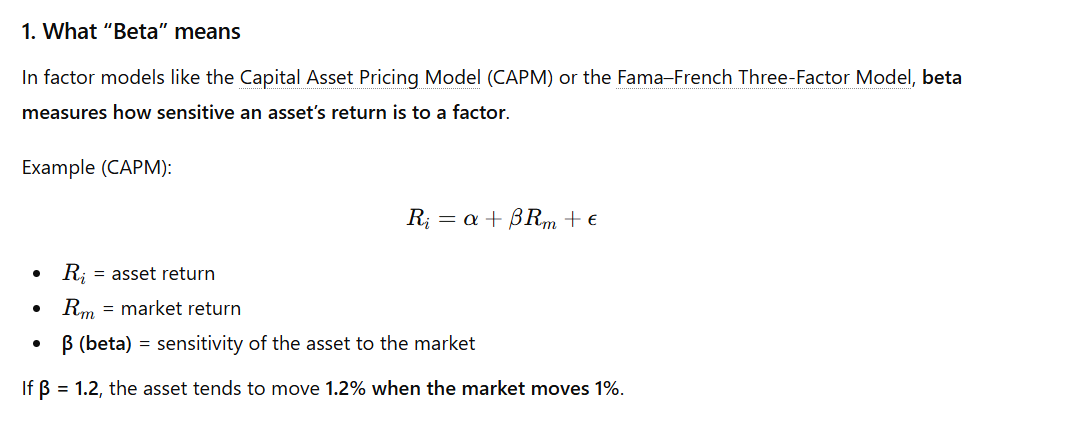


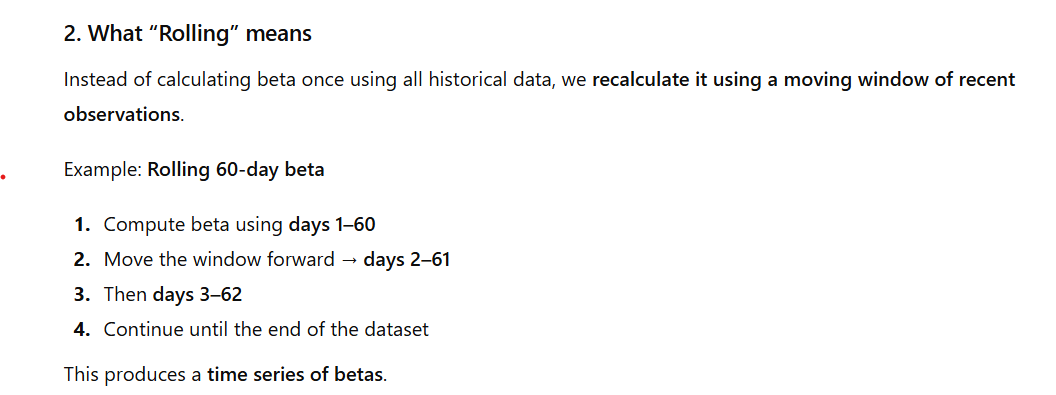

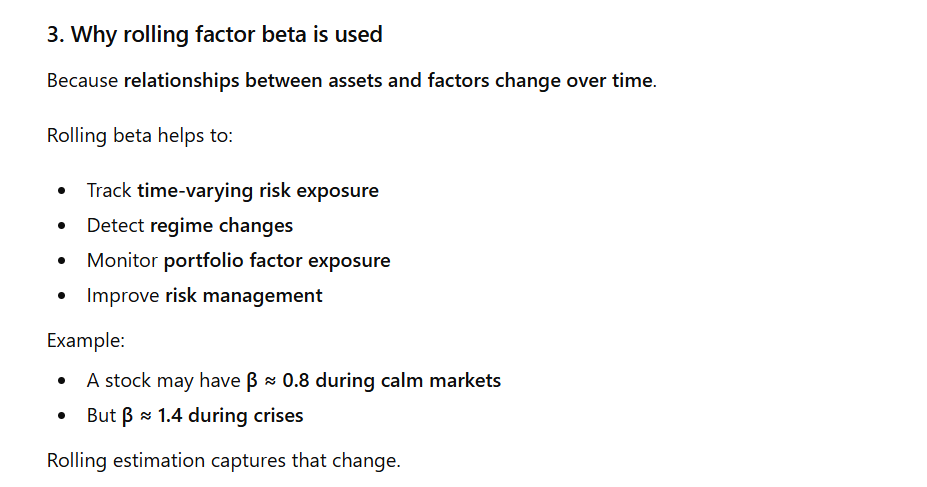


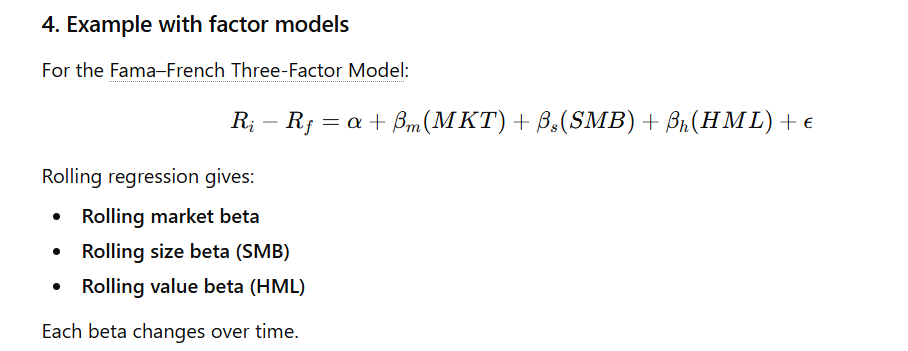



In [ ]:
def compute_betas(x):

    # Create the Regression Matrix (X)
    # A regression matrix usually refers to the matrix of input variables (regressors) used in a regression model
    X = sm.add_constant(x.drop('return_1m', axis=1))
    # x.drop('return_1m', axis=1) - Removes the dependent variable
    # sm.add_constant(...) - Adds an intercept column - This allows the regression to estimate alpha.

    y = x['return_1m'] #extracts the target variable.

    n_reg = X.shape[1] # Counts the number of columns in X
    # Example: const + 5 factors = 6 regressors
    # This is important because OLS needs at least this many observations

    window = min(24, len(x)) # Determines the rolling regression window length
    # Maximum window = 24 observations
    # If the asset has fewer observations, use its available length.

    # This prevents a mathematically invalid regression
    if window < n_reg:
        return None
    # Requirement for OLS: observations ≥ regressors
    # A regressor is simply an independent variable (input variable) used in a regression model to explain or predict another variable.

    # Create the Rolling Regression Model
    model = RollingOLS(   # Uses Rolling OLS from statsmodels.
        endog=y, # endog=y - Dependent variable (returns)
        exog=X, # Independent variables (factors)
        window=window, # Number of observations in each rolling regression.
        min_nobs=n_reg # Minimum observations required to estimate the regression.
    )

    return model.fit(params_only=True).params.drop('const', axis=1)
    # model.fit(params_only=True) - Fits the rolling regressions, params_only=True means: Only compute coefficients, Skip expensive statistics (t-stats, covariance). This makes the code much faster.
    # .params- Returns regression coefficients for each time point
    # .drop('const', axis=1) - Removes alpha, Remaining columns are factor betas: [MKT_beta, SMB_beta, HML_beta]

betas = factor_data.groupby(level=1, group_keys=False).apply(compute_betas)
# groupby(level=1)- Groups by the second level of the index
# .apply(compute_betas) - Runs the function for each ticker
# group_keys=False - Prevents pandas from adding an extra hierarchical index level - Keeps the output cleaner



# For each ticker:
# 1. Collect its return history.
# 2. Run rolling regressions (24-month window).
# 3. Estimate factor exposures (betas).
# 4. Store them over time.

# Used in:
# 1. Factor investing
# 2. Risk models
# 3. Portfolio construction

In [ ]:
betas

# Early Data Will Always Be Empty - Rolling window needs data

**Join the rolling factors data to the main features dataframe.**

In [ ]:
factors = ['SMB', 'HML', 'WML', 'MF']

# data = (data.join(betas.groupby('ticker').shift()))

# Join shifted factor values
data = data.join(
    betas.groupby('ticker')[factors].shift()
)
# You now have lagged factor values (previous time step) merged into data.
# .shift()
# → Shifts the data down by one row within each ticker group.
# → This means:

# Each row gets the previous period's factor values.
# Prevents look-ahead bias (common in finance).

# Fill missing values with group mean
data.loc[:, factors] = data.groupby('ticker', group_keys=False)[factors].apply(lambda x: x.fillna(x.mean()))
# .apply(lambda x: x.fillna(x.mean()))
# → For each ticker:
# If there are missing values (NaN)
# Replace them with the mean of that column within the same ticker

# Removes the 'adj close' column
data = data.drop('adj close', axis=1)

# Drop remaining missing values
data = data.dropna()

print(data.info())

print(data.head())

**At this point we have to decide on what ML model and approach to use for predictions etc**

## **6. For each month fit a K-Means Clustering Algorithm to group similar assets based on their features.**

Instead of clustering all your data at once, you:

- Split your dataset by month
- Run K-Means independently for each month
- Group assets into clusters based on their features (e.g., returns, volatility, volume, etc.)

📊 Why do this?


✅ Capture changing behavior

Assets don’t behave the same over time. Monthly clustering lets you:

- Detect regime shifts
- See how assets move between clusters

✅ Identify patterns

You can analyze:

- Which assets are consistently similar
- Which ones change groups often

✅ Portfolio or segmentation use

In finance:

- Group stocks with similar risk/return profiles each month

In business:

- Group customers/products dynamically

Simple Analogy

- Think of it like:

    Every month, you regroup students based on their latest test scores.
    
    The groups change because performance changes



K-Means Clustering
- You may want to initialize predefined centroids for each cluster based on your research.

- For visualization purpose of this tutorial we will initially rely on the ‘k-means++’ initialization.

- Then we will pre-define our centroids for each cluster.

### How does clustering help in stock analysis?

Clustering—especially using something like K-Means Clustering—is powerful in stock analysis because it helps you discover structure in the market without predefined labels. Instead of guessing which stocks are similar, clustering lets the data reveal those relationships.

📊 1. Identify Similar Stocks (Hidden Relationships)

Clustering groups stocks based on features like:

- Returns
- Volatility
- Trading volume
- Financial ratios

👉 Result: Stocks in the same cluster behave similarly.

Example:
You might find a cluster of:

- High-growth tech stocks
- Low-volatility defensive stocks

This is often more nuanced than traditional sectors.

💼 2. Portfolio Diversification

A key investing principle is diversification.

Clustering helps you:

- Avoid picking multiple stocks that behave the same
- Choose stocks from different clusters

👉 Instead of buying 5 similar banking stocks, you pick:

- 1 from a high-risk cluster
- 1 from a stable cluster
- 1 from a growth cluster

Result: Lower risk exposure

🔍 3. Detect Market Regimes

When you cluster monthly (like you mentioned earlier), you can see:

- How stock groupings change over time
- When the market shifts (bull vs bear phases)

👉 This relates to ideas from Quantitative Finance where markets are studied as dynamic systems.

🔄 4. Track Stock Behavior Changes

A stock moving between clusters is meaningful.

Example:

- Moves from “stable” cluster → “high volatility” cluster
👉 Could indicate:
- News impact
- Earnings surprise
- Increased risk

This is an early signal worth investigating.



📈 5. Better Risk Management

Clusters often reflect risk profiles:

- Low-risk (steady returns, low volatility)
- High-risk (big swings)

👉 You can:

- Allocate capital based on cluster risk
- Avoid overexposure to risky clusters


🤖 6. Feature Engineering for Models

Clusters can be used as inputs to other models.

Example:

- Add “cluster ID” as a feature in a prediction model
- Helps algorithms understand stock “type”

🧩 7. Pairs Trading / Relative Value

Clustering helps find similar stocks → useful for:

- Comparing valuations
- Finding mispriced stocks

👉 If two similar stocks diverge:

- One may be overvalued
- One undervalued

⚠️ Important Limitations

Clustering is useful, but not magic:

❗ It depends heavily on chosen features

❗ Clusters don’t explain why stocks behave similarly

❗ Market conditions can change quickly


🧠 Intuition (Simple Way to Think About It)

Clustering is like:

- “Automatically grouping stocks into personalities based on how they behave.”

Instead of labels like “IT” or “Banking,” you get:

- “Stable earners”
- “Momentum-driven”
- “Highly volatile”

### ELBOW METHOD
The Elbow Method is a technique used to determine the optimal number of clusters (k) for K-Means clustering. Here's a breakdown:

What it does:

- It runs the K-Means algorithm for a range of k values (e.g., from 1 to 10).
- For each k, it calculates the Within-Cluster Sum of Squares (WCSS), also known as inertia_. WCSS is the sum of squared distances between each point and the centroid of the cluster it belongs to. Essentially, it measures how compact the clusters are.

Why it's used:

- As k increases, the WCSS generally decreases because points are closer to their respective centroids. The goal is to find a k where adding more clusters doesn't significantly reduce the WCSS anymore.

How to interpret the plot:

- The plot shows WCSS on the y-axis and k (number of clusters) on the x-axis.
- You look for an "elbow point" on the graph. This is the point where the rate of decrease in WCSS sharply changes, forming an "elbow" shape.
- The k value at this elbow point is often considered the optimal number of clusters because it represents a good balance between minimizing WCSS and not adding too many clusters (which could lead to overfitting or less meaningful groups).

In your code, the plot you generated would help you visualize this WCSS reduction and identify that 'elbow' to choose an appropriate n_clusters for your K-Means algorithm.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
# Imports a tool to standardize data (mean = 0, std = 1).
# Important because KMeans is sensitive to scale.
import pandas as pd


# 1. Extract numerical features (excluding 'cluster' if it exists)
# Ensure 'ticker' and 'date' are not treated as features for clustering
features_df = data.copy() # Creates a copy of your dataset (data) so the original isn’t modified.
if 'cluster' in features_df.columns:
    features_df = features_df.drop('cluster', axis=1)

# Select only numeric columns for scaling and clustering
numeric_features = features_df.select_dtypes(include=['number'])

# Handle potential NaN values by dropping them, as KMeans doesn't handle them
numeric_features = numeric_features.dropna()

# Check if numeric_features is empty after dropping NaNs
if numeric_features.empty:
    print("Warning: No numeric features left after dropping NaNs. Cannot perform Elbow Method.")
else:
    # 2. Scale these features
    scaler = StandardScaler() # Creates a scaler object
    scaled_features = scaler.fit_transform(numeric_features) # Fits the scaler to data and transforms it: Mean → 0, Standard deviation → 1
    scaled_features_df = pd.DataFrame(scaled_features, columns=numeric_features.columns, index=numeric_features.index) # Converts scaled data back into a DataFrame. Keeps:Original column names, Original row indices

    # 3. Calculate WCSS for a range of k values
    wcss = []
    # Typically, you'd test k from 1 up to a reasonable number, e.g., 10 or 15
    k_range = range(1, 11)

    for i in k_range:
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init for robust centroid initialization
        # Creates a KMeans model:
        # n_clusters=i → number of clusters
        # init='k-means++' → smarter initialization
        # random_state=42 → reproducibility
        # n_init=10 → run algorithm 10 times and pick best

        #init='k-means++'
        # Controls how initial cluster centers (centroids) are chosen.
        # 'k-means++' is a smart method that:
          # Spreads centroids apart initially
          # Leads to faster convergence
          # Usually gives better results than random initialization

        # random_state=42
        # Fixes the random seed.
        # Ensures reproducibility:
          # You’ll get the same results every time you run the code
        # 👉 Why 42? It’s just a convention (popular in programming culture

        # n_init=10
        # Number of times KMeans runs with different initial centroids.
        # The algorithm:
          # Runs 10 times
          # Picks the best result (lowest WCSS / inertia)
        # 👉 This reduces the chance of:
          # Getting stuck in a bad local minimum
          # Poor clustering due to unlucky initialization

        # Create a KMeans model that tries i clusters, initializes smartly, runs 10 times with different starting points, and gives consistent results every time

        kmeans.fit(scaled_features_df) # Fits the model to the scaled data.
        wcss.append(kmeans.inertia_) # inertia_ is the WCSS
        # Stores the WCSS value: inertia_ = sum of squared distances to cluster centers Lower = better clustering (but too low may overfit)

    # 4. Plot the WCSS values against the number of clusters (k)
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, wcss, marker='o', linestyle='--') # Plots: X-axis → number of clusters, Y-axis → WCSS, Adds markers (o) and dashed line.
    plt.title('Elbow Method for Optimal K')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
    plt.xticks(k_range) # Ensures all values from 1–10 appear on the x-axis
    plt.grid(True) # Adds grid lines for better readability
    plt.show() # Displays the plot

In [ ]:
from sklearn.cluster import KMeans

# data = data.drop('cluster', axis=1)

def get_clusters(df):
    df['cluster'] = KMeans(
    n_clusters=4,
    random_state=0 # random_state=0 → Ensures reproducible results
).fit(df).labels_
    # .fit(df)- Trains the model on the data df. It: Computes cluster centers and Assigns each row to the nearest center
    # .labels_ - After fitting, this gives: Cluster assignment for each row
    return df

data = data.dropna().groupby('date', group_keys=False).apply(get_clusters)
# .groupby('date', group_keys=False) - Splits the dataset into groups based on each unique date.
# data.dropna() - Removes rows with missing values
# .apply(get_clusters) - Applies your function separately to each date group

data

In [ ]:
def plot_clusters(data):

  # Filters the dataset into 5 subsets, one for each cluster
    cluster_0 = data[data['cluster']==0]
    cluster_1 = data[data['cluster']==1]
    cluster_2 = data[data['cluster']==2]
    cluster_3 = data[data['cluster']==3]
    cluster_4 = data[data['cluster']==4]

    # Plots cluster 0 points:
          # cluster_0.iloc[:,5] → column at index 5 (X-axis)
          # cluster_0.iloc[:,1] → column at index 1 (Y-axis)
          # color='red' → color for this cluster
          # label='cluster 0' → used in legend
    plt.scatter(cluster_0.iloc[:,5] , cluster_0.iloc[:,1] , color = 'red', label='cluster 0')
    plt.scatter(cluster_1.iloc[:,5] , cluster_1.iloc[:,1] , color = 'green', label='cluster 1')
    plt.scatter(cluster_2.iloc[:,5] , cluster_2.iloc[:,1] , color = 'blue', label='cluster 2')
    plt.scatter(cluster_3.iloc[:,5] , cluster_3.iloc[:,1] , color = 'black', label='cluster 3')
    plt.scatter(cluster_4.iloc[:,5] , cluster_4.iloc[:,1] , color = 'yellow', label='cluster 4')

    plt.xlabel('ATR')
    plt.ylabel('RSI')
    plt.legend()
    plt.show()
    return

In [ ]:
plt.style.use('ggplot')

for i in data.index.get_level_values('date').unique().tolist():

    g = data.xs(i, level=0)

    plt.title(f'Date {i}')

    plot_clusters(g)

**Apply Pre Defined Centroids** - Dynamically determine target_rsi_values based on RSI distribution in the 'data' DataFrame


In [ ]:
import numpy as np

# Dynamically determine target_rsi_values based on RSI distribution in the 'data' DataFrame

# Assuming 'rsi' is a column in the 'data' DataFrame
# We select 4 quantiles to match the 4 clusters previously used (from get_clusters function).
dynamic_target_rsi_values = data['rsi'].dropna().quantile([0.25, 0.50, 0.75, 0.95]).to_list()

# Dynamically determine the number of features for the centroids
# Exclude the 'cluster' column and consider only numeric types.
# 'date' and 'ticker' are multi-index levels and are not counted as columns by default.
# We use `errors='ignore'` for `drop` in case 'cluster' column is not present yet.
features_for_clustering = data.drop(columns=['cluster'], errors='ignore').select_dtypes(include=np.number)
num_features = features_for_clustering.shape[1]

# Initialize initial_centroids with dynamic RSI values and dynamic number of features
initial_centroids = np.zeros((len(dynamic_target_rsi_values), num_features))

# Assign the dynamic RSI values to the 'rsi' column's index.
# We need to find the index of the 'rsi' column among the numeric features used for clustering.
rsi_column_index = features_for_clustering.columns.get_loc('rsi')

initial_centroids[:, rsi_column_index] = dynamic_target_rsi_values

display(initial_centroids)

# target_rsi_values = [30, 45, 55, 70]

# initial_centroids = np.zeros((len(target_rsi_values), 18))

# initial_centroids[:, 6] = target_rsi_values

# initial_centroids

## 7. **For each month select assets based on the cluster and form a portfolio based on Efficient Frontier max sharpe ratio optimization**

1. First we will filter only stocks corresponding to the cluster we choose based on our hypothesis.

2. Momentum is persistent and my idea would be that stocks clustered around RSI 70 centroid should continue to outperform in the following month - thus I would select stocks corresponding to cluster 3.



Each month, you:

1. Group stocks into clusters (based on features like RSI, returns, volatility, etc.)
2. Pick one cluster based on a hypothesis
3. Select stocks from that cluster
4. Build a portfolio using Efficient Frontier → Max Sharpe Ratio

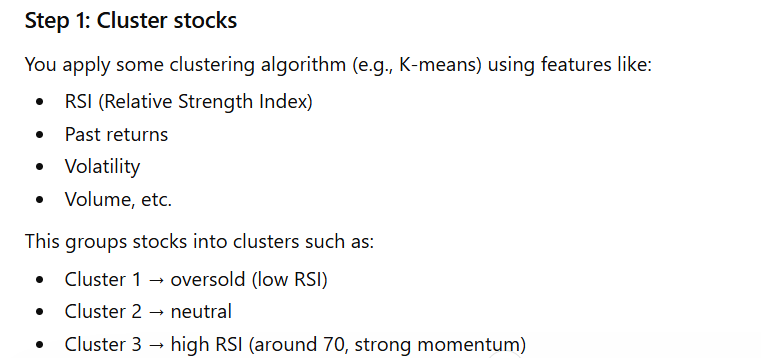

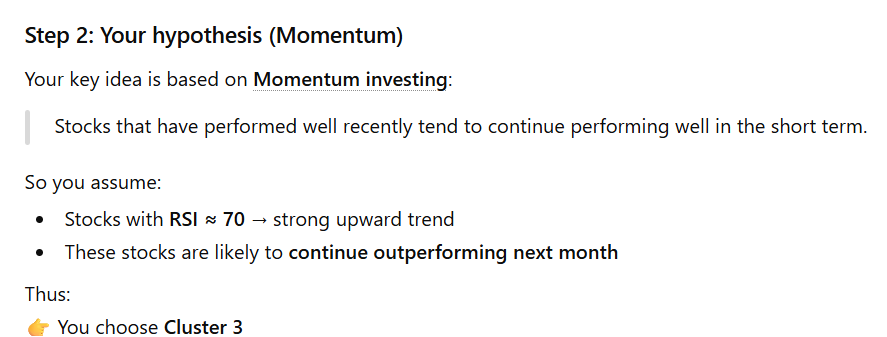

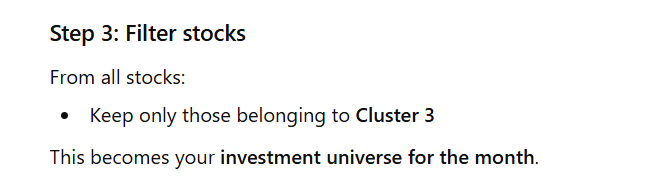

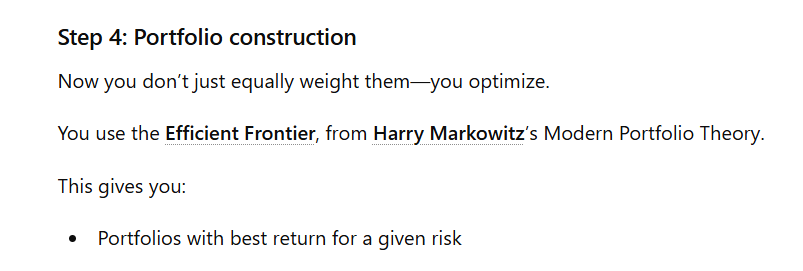

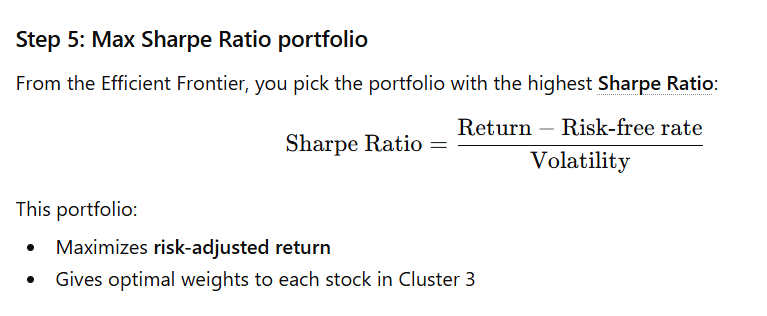

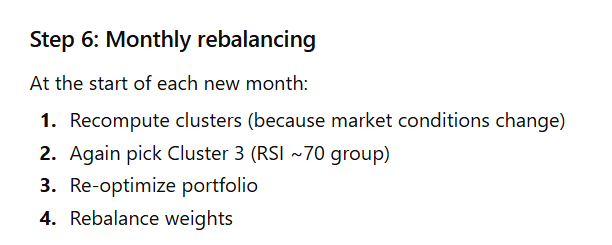

**Why this approach makes sense**

You’re combining three powerful ideas:

(1) Clustering → smarter stock selection

Instead of picking randomly, you:

- Group similar stocks
- Target a specific market behavior

(2) Momentum → alpha generation

Momentum is one of the most documented anomalies in finance:

- Works well in medium-term horizons (1–6 months)

(3) Efficient Frontier → risk control

Instead of just chasing returns:

- You optimize trade-off between risk & return


**Think of it like this:**

- You scan the market and find stocks already trending up strongly
- You assume: “winners keep winning”
- But instead of betting equally:
- You carefully allocate money to maximize reward per unit risk


**Potential risks / caveats**

Your logic is solid, but watch out for:

- Momentum crashes (sudden reversals)
- RSI overbought trap (70 doesn’t always mean continuation)
- Cluster instability (clusters may shift month to month)
- Overfitting if tuned too tightly

#### **Efficient Frontier**



```
Think of buying a car:

Risk = fuel consumption + maintenance cost
Return = performance/speed

Efficient Frontier = cars that give:

Best performance for fuel cost
Or lowest fuel cost for given performance

Anything else is a bad deal.
```



- The Efficient Frontier is a core idea in investing that helps you choose the best possible portfolio for a given level of risk.

- The Efficient Frontier is a core concept in modern portfolio theory that defines the set of investment portfolios offering the highest expected return for a given level of risk—or the lowest risk for a given expected return. Introduced by economist Harry Markowitz in 1952, it remains a cornerstone of quantitative portfolio management and asset allocation.

- The Efficient Frontier is: The set of portfolios that give the maximum return for each level of risk.

Key facts
- Originator: Harry Markowitz (1952)

- Framework: Modern Portfolio Theory (MPT)

- Purpose: Identify optimal risk–return trade-offs

- Graph axes: X = risk (standard deviation), Y = expected return

- Shape: Upward-sloping concave curve (hyperbolic form)


If a portfolio is not on the Efficient Frontier, it means:

❌ You’re taking too much risk for too little return
❌ OR you could get higher return without increasing risk

So rational investors only choose portfolios on the frontier.


Note: The Efficient Frontier helps you answer:

**“Given my risk level, what is the best possible return I can achieve?”**

**Applications and Limitations**

The Efficient Frontier underpins asset allocation, fund design, and advisory tools such as robo-advisors. It helps investors visualize diversification benefits and align portfolios with their risk tolerance. However, it depends heavily on accurate estimates of expected returns, volatilities, and correlations. Because these inputs shift over time, the frontier is dynamic, and its predictive power can weaken if market behavior diverges from historical patterns.

**Critiques**

Critics note that the model assumes rational, risk-averse investors and normally distributed returns—conditions often violated in real markets. It also ignores taxes, transaction costs, and behavioral biases. Despite these limitations, the Efficient Frontier remains an enduring analytical framework for balancing risk and reward in portfolio management.

In [ ]:
# Filter rows for a specific cluster
filtered_df = data[data['cluster']==3].copy()
# selecting only the rows where the column cluster equals 3.
# .copy() ensures you’re working on a separate DataFrame (avoids unintended side effects).


# Reset one level of a MultiIndex
filtered_df = filtered_df.reset_index(level=1)
# Removes level 1 (likely ticker) from the index
# Moves it into a column

# Shift the index (dates) forward by 1 day
filtered_df.index = filtered_df.index+pd.DateOffset(1)
# Adds 1 day to every value in the index (assumes index is datetime).
# Example: 2024-01-01 → 2024-01-02

# Rebuild the MultiIndex
filtered_df = filtered_df.reset_index().set_index(['date', 'ticker'])

# Extract unique dates
dates = filtered_df.index.get_level_values('date').unique().tolist()
# Gets all unique values from the date level of the MultiIndex.
# Converts them into a Python list.

# Build a dictionary mapping dates → tickers
fixed_dates = {}

for d in dates:
    fixed_dates[d.strftime('%Y-%m-%d')] = filtered_df.xs(d, level=0).index.tolist()
# For each date:
# d.strftime('%Y-%m-%d')
# → Converts date to string like "2024-01-02"
# filtered_df.xs(d, level=0)
# → Selects all rows for that specific date
# .index.tolist()
# → Gets all tickers for that date

fixed_dates

**Define portfolio optimization function**

- We will define a function which optimizes portfolio weights using PyPortfolioOpt package and EfficientFrontier optimizer to maximize the sharpe ratio.

- To optimize the weights of a given portfolio we would need to supply last 1 year prices to the function.

- Apply single stock weight bounds constraint for diversification (minimum half of equaly weight and maximum 10% of portfolio).

In [ ]:
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

def optimize_weights(prices, lower_bound=0):

    returns = expected_returns.mean_historical_return(prices=prices,
                                                      frequency=252)

    cov = risk_models.sample_cov(prices=prices,
                                 frequency=252)

    ef = EfficientFrontier(expected_returns=returns,
                           cov_matrix=cov,
                           weight_bounds=(lower_bound, .1),
                           solver='SCS')

    weights = ef.max_sharpe()

    return ef.clean_weights()

- Download Fresh Daily Prices Data only for short listed stocks.

In [ ]:
stocks = data.index.get_level_values('ticker').unique().tolist()

new_df = yf.download(tickers=stocks,
                     start=data.index.get_level_values('date').unique()[0]-pd.DateOffset(months=12),
                     end=data.index.get_level_values('date').unique()[-1])

new_df

- Calculate daily returns for each stock which could land up in our portfolio.

- Then loop over each month start, select the stocks for the month and calculate their weights for the next month.

- If the maximum sharpe ratio optimization fails for a given month, apply equally-weighted weights.

- Calculated each day portfolio return.

In [ ]:
returns_dataframe = np.log(new_df['Adj Close']).diff()

portfolio_df = pd.DataFrame()

for start_date in fixed_dates.keys():

    try:

        end_date = (pd.to_datetime(start_date)+pd.offsets.MonthEnd(0)).strftime('%Y-%m-%d')

        cols = fixed_dates[start_date]

        optimization_start_date = (pd.to_datetime(start_date)-pd.DateOffset(months=12)).strftime('%Y-%m-%d')

        optimization_end_date = (pd.to_datetime(start_date)-pd.DateOffset(days=1)).strftime('%Y-%m-%d')

        optimization_df = new_df[optimization_start_date:optimization_end_date]['Adj Close'][cols]

        success = False
        try:
            weights = optimize_weights(prices=optimization_df,
                                   lower_bound=round(1/(len(optimization_df.columns)*2),3))

            weights = pd.DataFrame(weights, index=pd.Series(0))

            success = True
        except:
            print(f'Max Sharpe Optimization failed for {start_date}, Continuing with Equal-Weights')

        if success==False:
            weights = pd.DataFrame([1/len(optimization_df.columns) for i in range(len(optimization_df.columns))],
                                     index=optimization_df.columns.tolist(),
                                     columns=pd.Series(0)).T

        temp_df = returns_dataframe[start_date:end_date]

        temp_df = temp_df.stack().to_frame('return').reset_index(level=0)\
                   .merge(weights.stack().to_frame('weight').reset_index(level=0, drop=True),
                          left_index=True,
                          right_index=True)\
                   .reset_index().set_index(['Date', 'index']).unstack().stack()

        temp_df.index.names = ['date', 'ticker']

        temp_df['weighted_return'] = temp_df['return']*temp_df['weight']

        temp_df = temp_df.groupby(level=0)['weighted_return'].sum().to_frame('Strategy Return')

        portfolio_df = pd.concat([portfolio_df, temp_df], axis=0)

    except Exception as e:
        print(e)

portfolio_df = portfolio_df.drop_duplicates()

portfolio_df

### 8. Visualize Portfolio returns and compare to SP500 returns.

In [ ]:
spy = yf.download(tickers='SPY',
                  start='2015-01-01',
                  end=dt.date.today())

spy_ret = np.log(spy[['Adj Close']]).diff().dropna().rename({'Adj Close':'SPY Buy&Hold'}, axis=1)

portfolio_df = portfolio_df.merge(spy_ret,
                                  left_index=True,
                                  right_index=True)

portfolio_df

In [ ]:
import matplotlib.ticker as mtick

plt.style.use('ggplot')

portfolio_cumulative_return = np.exp(np.log1p(portfolio_df).cumsum())-1

portfolio_cumulative_return[:'2023-09-29'].plot(figsize=(16,6))

plt.title('Unsupervised Learning Trading Strategy Returns Over Time')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.ylabel('Return')

plt.show()

# Project 2: Twitter Sentiment Investment Strategy

## What is Sentiment Investing?

This approach focuses on analyzing how people feel about certain stocks, industries, or the overall market. It assumes that public sentiment can impact stock prices and markets.

For example, if many people are positive about a particular company on twitter, it might indicate potential for that company's stock to perform well.

###What will we exactly do?

1. Load NASDAQ stocks with sentiment data.
2. Calculate a quantative feature of the engagement ratio in Twitter of each stock.
3. Every month rank all stocks and construct an equal-weight protfolio.
4. Compare it against NASDAQ performance.

Note: No machine learning strategy is involved in it unlike project 1. The idea is here to show you how alternative or different data in this case sentiment can help us to create a quant feature and then create potential strategy out of it.






# Project 3: Intraday Strategy Using GARCH Model

## What does Intraday Strategy Means?
This approach involves buying and selling financial assets within the same trading day to profit from short-term price movements. Intraday traders use technical analysis, real-time data and risk management techniques to make quick decisions, aiming to capitalize on market volatility.


### What we will do?
1. Load simulated daily data and simulated 5 minute-data.
2. Define function to fit GARCH model(rolling window model) and predict 1-day ahead volatility in a rolling window.
3. Calculate prediction premium and form a daily signal from it.
4. Merge with intraday data and calculate intraday indicators to form the intraday signal.
5. Generate the position entry and hold until the end of the day.
6. Calculate the final strategy returns.

Note: To show how predicting volatlity works in intraday strategies.

